## Load modules

Close the notebook (using the open tabs menu) and restart

In [1]:
!pip install --no-index seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/seaborn-0.13.2+computecanada-py3-none-any.whl


## Import packages 

In [1]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import subprocess
import os
import scipy.stats as stats
from collections import Counter

import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Import your sample datasheet. If you have already run part of the notebook, some additional columns might be there.

In [2]:
sample_datasheet = pd.read_csv('./screen_10_2024_sample_list_with_ODs.csv', sep=',', index_col=0)
sample_datasheet

,sample_name,timepoint,condition,ATC,replicate,fastq_path,Unnamed: 7,n_gens_P1,n_gens_P2,n_gens_P3,total_gens
sample,,,,,,,,,,,
1,ATC_1_T0,T0,control,Yes,1,./Run1/ATC_1_T0_S1,NaN,NaN,NaN,NaN,NaN
2,ATC_2_T0,T0,control,Yes,2,./Run1/ATC_2_T0_S2,NaN,NaN,NaN,NaN,NaN
3,ATC_3_T0,T0,control,Yes,3,./Run1/ATC_3_T0_S3,NaN,NaN,NaN,NaN,NaN
4,noATC_1_T0,T0,control,No,1,./Run1/noATC_1_T0_S4,NaN,NaN,NaN,NaN,NaN
5,noATC_2_T0,T0,control,No,2,./Run1/noATC_2_T0_S5,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
68,ATC_2_MMS,T3,MMS,Yes,2,./Run1/ATC_2_MMS_S68,NaN,7.852373,7.426265,7.622052,22.900690
69,ATC_3_MMS,T3,MMS,Yes,3,./Run1/ATC_3_MMS_S69,NaN,7.870365,7.491853,7.734710,23.096927
70,noATC_1_MMS,T3,MMS,No,1,./Run1/noATC_1_MMS_S70,NaN,7.891176,7.562242,7.826548,23.279967


## Get the number of raw reads for each file (run once then skip afterwards)

In [3]:
raw_read_count_dict = {}
# empty dictionnary to hold the library:n_reads info

for sample in sample_datasheet.index:
    # loop through samples in datasheet
    
    R1_fastq_path = sample_datasheet.at[sample,'fastq_path']+'_R1_001.fastq.gz'
    # path to the fastq file 
    command = 'zgrep -o \'@LH\' '+R1_fastq_path+' | wc -l'
    # command to count number of fastq headers in the file, header guide from: https://www.biostars.org/p/198143/#198150 
    # @HWI-Mxxxx or @Mxxxx - MiSeq
    # @HWUSI - GAIIx
    # @HWI-Dxxxx - HiSeq 2000/2500
    # @Kxxxx - HiSeq 3000(?)/4000
    # @Nxxxx - NextSeq 500/550
    # @Axxxxx - NovaSeq
    # @Vxxxxx = NextSeq 2000
    # Edit (08/2022)
    # @AAxxxxx - NextSeq 2000 P1/P2/P3
    # @Hxxxxxx - NovaSeq S1/S2/S4
    
    output  = subprocess.check_output('zgrep -o \'@LH\' '+R1_fastq_path+' | wc -l', shell=True, text=True)
    raw_read_count_dict[sample] = int(output.strip('\n'))
    # run the command and store the output
    
sample_datasheet['raw_reads'] = pd.Series(raw_read_count_dict)
    
sample_datasheet.to_csv('./screen_10_2024_sample_list_updated.csv', sep=',')
    
# this step takes ~18s to complete for a 3M read dataset, so expect run time to scale accordingly. 
# To avoid redoing it, we save the dataframe after finishing this step -> 10M reads/min

In [4]:
sum(raw_read_count_dict.values())
# total number of reads sequenced

108901924

Text(0, 0.5, 'Number of reads')

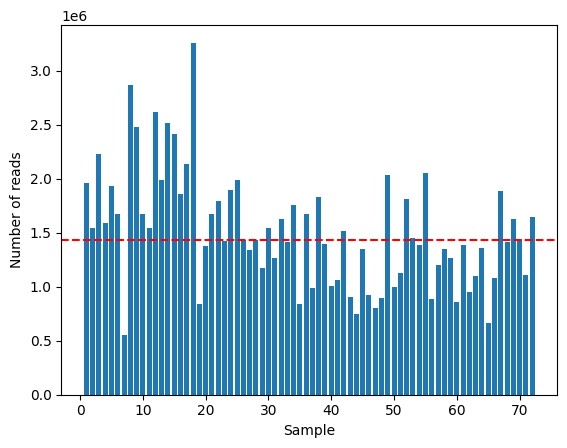

In [5]:
plt.bar([x for x in sample_datasheet.index], [sample_datasheet.at[x, 'raw_reads'] for x in sample_datasheet.index])
plt.axhline(np.median([sample_datasheet.at[x, 'raw_reads'] for x in sample_datasheet.index]), color='r', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('Number of reads')

## Prepare directories

In [6]:
list_dir = os.listdir()

if 'logs' not in list_dir:
    os.mkdir('logs')
if 'fastqc_outputs' not in list_dir:
    os.mkdir('fastqc_outputs')
if 'pear_output' not in list_dir:
    os.mkdir('pear_output')
if 'vsearch_trim' not in list_dir:
    os.mkdir('vsearch_trim')
if 'vsearch_aggregate' not in list_dir:
    os.mkdir('vsearch_aggregate')
if 'barcode_counts' not in list_dir:
    os.mkdir('barcode_counts')
# If they are not already present, create directories for intermediate analysis files

## Write bash script to run FastQC on samples (QC for sequencer output)
Change the time as a function of the number of reads. A 14 * 0.85M test dataset took about 33s, so about 1.4M reads/min. Consider increasing the runtime if you have > 85M reads per sample.

In [7]:
n_files = len(sample_datasheet.index)*2
print(n_files)

with open('./run_fastqc.sh', 'w') as dest:
    
    

    dest.write('#!/bin/bash'+'\n')                         # bash header
    dest.write('#SBATCH --account=def-rshap'+'\n')         # compute canada PI account
    dest.write('#SBATCH --cpus-per-task=48\n')          # number of cpus for the job
    dest.write('#SBATCH --mem='+str(math.ceil(((n_files+1)*0.5)))+'G\n')                    # RAM for the job
    dest.write('#SBATCH --time=0-01:00'+'\n')              # time limit
    dest.write('#SBATCH --output=logs/slurm-%j.out'+'\n')  # directory to store logs limit
    dest.write('\n'+'\n')
    
    dest.write('module load fastqc'+'\n')
    # load the fastqc module
    
    fastqc_command = 'fastqc --outdir fastqc_outputs -t '+str(n_files)+ ' --extract --delete ./data/*.fastq.gz'
    dest.write(fastqc_command)
   

144


## Write bash script
Change the time as a function of the number of reads. A 3M test dataset took about 5 mins and 3 GB of RAM, so about 0.6M reads/million reads and 1 GB RAM per million reads.

In [8]:
with open('./process_barcodes.sh', 'w') as dest:
    dest.write('#!/bin/bash'+'\n')                         # bash header
    dest.write('#SBATCH --account=def-rshap'+'\n')         # compute canada PI account
    dest.write('#SBATCH --cpus-per-task=16'+'\n')          # number of cpus for the job
    dest.write('#SBATCH --mem=5G'+'\n')                    # RAM for the job
    dest.write('#SBATCH --time=0-02:00'+'\n')              # time limit
    dest.write('#SBATCH --output=logs/slurm-%j.out'+'\n')  # directory to store logs limit
    dest.write('\n'+'\n')
    
    dest.write('module load StdEnv/2020'+'\n') # load software modules 
    
    dest.write('module load pear'+'\n')
    dest.write('module load vsearch'+'\n')
    
    for sample in sample_datasheet.index:
        dest.write('date'+'\n')
        fastq_path = sample_datasheet.at[sample, 'fastq_path']
        fastq_R1 = fastq_path +'_R1_001.fastq.gz'
        fastq_R2 = fastq_path +'_R2_001.fastq.gz'
        pear_out = './pear_output/'+str(sample)
        
        pear_command = 'pear -f '+fastq_R1+' -r '+fastq_R2+' -o '+pear_out+' -j 16 -u 0.01 -q 20 -m 154 -n 145'+'\n'
        dest.write(pear_command)
        
        assembled_reads = './pear_output/'+str(sample)+'.assembled.fastq'
        dest.write('date'+'\n')
        
        filter_out = './vsearch_trim/'+str(sample)+'_trimmed.fastq'
        filter_rc = './vsearch_trim/'+str(sample)+'_trimmed_rc.fastq'
        
        filter_command = 'vsearch --fastx_filter '+assembled_reads+' --fastq_stripleft 20 --fastq_stripright 43 --fastaout '+filter_out+'\n'
        rc_command = 'vsearch --fastx_revcomp '+filter_out+' --fastaout '+filter_rc+'\n'
        
        dest.write(filter_command)
        dest.write(rc_command)
        
        dest.write('date'+'\n')
        
        aggregate_fasta = './vsearch_aggregate/'+str(sample)+'_aggregate.fasta'
        aggregate_command = 'vsearch --derep_fulllength '+filter_rc+' --relabel seq --output '+aggregate_fasta+' --sizeout'+'\n'
        
        dest.write(aggregate_command)
        
    dest.write('date'+'\n')
        
        
        



In [9]:
assembled_read_count = {}

for sample in sample_datasheet.index:
    assembled_reads = './pear_output/'+str(sample)+'.assembled.fastq'
    command = 'grep -o \'@LH\' '+assembled_reads+' | wc -l'
    
    output  = subprocess.check_output(command, shell=True, text=True)
    assembled_read_count[sample] = int(output.strip('\n'))
    
sample_datasheet['assembled_reads'] = pd.Series(assembled_read_count)
    
sample_datasheet.to_csv('./screen_10_2024_sample_list_updated.csv', sep=',')

In [10]:
sample_datasheet

,sample_name,timepoint,condition,ATC,replicate,fastq_path,Unnamed: 7,n_gens_P1,n_gens_P2,n_gens_P3,total_gens,raw_reads,assembled_reads
sample,,,,,,,,,,,,,
1,ATC_1_T0,T0,control,Yes,1,./Run1/ATC_1_T0_S1,NaN,NaN,NaN,NaN,NaN,1965902,1378825
2,ATC_2_T0,T0,control,Yes,2,./Run1/ATC_2_T0_S2,NaN,NaN,NaN,NaN,NaN,1543645,1338649
3,ATC_3_T0,T0,control,Yes,3,./Run1/ATC_3_T0_S3,NaN,NaN,NaN,NaN,NaN,2227541,1750817
4,noATC_1_T0,T0,control,No,1,./Run1/noATC_1_T0_S4,NaN,NaN,NaN,NaN,NaN,1594889,1283867
5,noATC_2_T0,T0,control,No,2,./Run1/noATC_2_T0_S5,NaN,NaN,NaN,NaN,NaN,1929856,1650342
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,ATC_2_MMS,T3,MMS,Yes,2,./Run1/ATC_2_MMS_S68,NaN,7.852373,7.426265,7.622052,22.900690,1412316,1136625
69,ATC_3_MMS,T3,MMS,Yes,3,./Run1/ATC_3_MMS_S69,NaN,7.870365,7.491853,7.734710,23.096927,1623624,1245994
70,noATC_1_MMS,T3,MMS,No,1,./Run1/noATC_1_MMS_S70,NaN,7.891176,7.562242,7.826548,23.279967,1447242,878614


Text(0, 0.5, 'Number of merged reads')

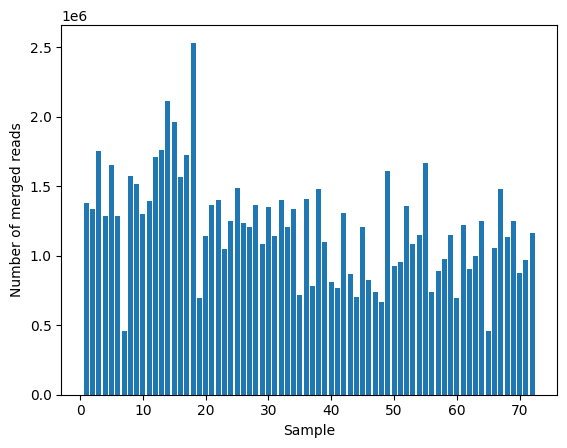

In [11]:
plt.bar([x for x in sample_datasheet.index], [sample_datasheet.at[x, 'assembled_reads'] for x in sample_datasheet.index])
plt.xlabel('Sample')
plt.ylabel('Number of merged reads')

## Import sgRNA/barcode dataframe

In [14]:
sgRNA_df = pd.read_csv('./sgrna_annot.csv', index_col=0)
sgRNA_df.at[539, 'control'] = 2


In [15]:
non_count_cols = list(sgRNA_df.columns)
# list of columns present in the starting dataframe

In [16]:
def get_dict_of_seq(fasta_file):
    """ function that converts a fasta file to a dictionnary of sequences
    fasta_file: the input fasta file
    """
    
    file_fasta_dict = {}
    # output dict of imported seqs
    
    with open(fasta_file, 'r') as fasta:    
        for line in fasta:
            # loops through the file

            if line.startswith('>') == True:
                seq_info = line.strip('>').strip('\n').split('\t')[0]
                file_fasta_dict[seq_info] = ''
                # checks if seq header

            else:
                file_fasta_dict[seq_info] += line.strip('\n')
                # If not, append nt to current seq
                
    return file_fasta_dict

## Count sgRNAs using perfect match, with a 8nt anchor

In [17]:
def count_barcodes_perfect_match(fasta_seq_dict, barcode_dict):
    # from a dictionnary of aggregate fasta entry and the sgRNA table, count the number of reads associated
    # with each guide, only counting perfect sequence matches to the sgRNA with an 8 nt "anchor" in 3' and 5'
    # to prevent +1/-1 shifted sgRNA from contaminating one another
       
    sample_sgRNA_counter = Counter()
    # empty counter to store sgRNA count values
    
    for key in list(fasta_seq_dict.keys()):
        # iterate trough aggregate sequences
        
        seq_count = int(key.split(';size=')[1])
        # get sequence counts for the fasta entry
        
        n_match = 0
        barcode_ids = []
        # containers for debugging
        
        for barcode in list(barcode_dict.keys()):
            # iterate through sgRNA sequences
            
            if "AATTTCGA"+barcode+"GTTTTAGA" in fasta_seq_dict[key]:
                # add 8nt in 5' and 3' to anchor the sgRNA
                n_match+=1
                barcode_ids.append(barcode)
                # increment match counter and match list for debugging
                if n_match > 1:
                    print(key, n_match, barcode_ids)
                    # print a warning if a sequence matches multiple sgRNAs
                    
                sample_sgRNA_counter[barcode_dict[barcode]] +=seq_count
                # add sgRNA count to Counter
                
            elif barcode == 'TGAAGAGCCATTAATGCTCTTCC':
                if 'GGAAGAGCATTAATGGCTCTTCA' in fasta_seq_dict[key]:
                    n_match+=1
                    barcode_ids.append(barcode)
                    # increment match counter and match list for debugging
                    if n_match > 1:
                        print(key, n_match, barcode_ids)
                        # print a warning if a sequence matches multiple sgRNAs
                    
                    sample_sgRNA_counter[barcode_dict[barcode]] +=seq_count
                    # add sgRNA count to Counter
                    
        if n_match>1:
            print(key)
                    
        #if seq_count>50 and n_match==0:
        #    print(key, fasta_seq_dict[key])
                    
    return sample_sgRNA_counter

In [18]:
3/0.66

4.545454545454545

As it is, this takes ~40s for 3M reads, so about 4.5M reads per minute. Can be left to run on its own for a while if you have a very large dataset.

In [19]:
usable_reads_dict = {}

barcode_dict = {}

for sgRNA in sgRNA_df.index:
    barcode = sgRNA_df.at[sgRNA, 'Barcode']
    barcode_dict[barcode] = sgRNA

for sample in sample_datasheet.index:
    aggregate_fasta = './vsearch_aggregate/'+str(sample)+'_aggregate.fasta'
    fasta_dict = get_dict_of_seq(aggregate_fasta)
    
    
    
    
    sgRNA_counter = count_barcodes_perfect_match(fasta_dict, barcode_dict)
    usable_reads_dict[sample] = sum(sgRNA_counter.values())
    
    if sample_datasheet.at[sample, 'ATC'] == 'Yes':
        col_name = 'ATC_'
    elif sample_datasheet.at[sample, 'ATC'] == 'No':
        col_name = 'NoATC_'
    
    col_name += sample_datasheet.at[sample, 'condition']+'_'
    col_name += sample_datasheet.at[sample, 'timepoint']+'_'
    col_name += str(sample_datasheet.at[sample, 'replicate'])
    
    sgRNA_df[col_name] = pd.Series(sgRNA_counter)
    

    
#usable_reads_dict

In [20]:
pd.Series(sgRNA_counter)

545    25635
540    23933
483    20853
381    20457
164    17727
       ...  
200        7
8          7
308        4
496        3
552        4
Length: 520, dtype: int64

In [21]:
sample_datasheet['usable_reads'] = pd.Series(usable_reads_dict)
usable_stats = stats.linregress(sample_datasheet.raw_reads, sample_datasheet.usable_reads)
print(usable_stats)

LinregressResult(slope=np.float64(0.6138659959818927), intercept=np.float64(193951.81888049468), rvalue=np.float64(0.933640787764693), pvalue=np.float64(6.25853048302697e-33), stderr=np.float64(0.028150314470881052), intercept_stderr=np.float64(45109.85169438298))


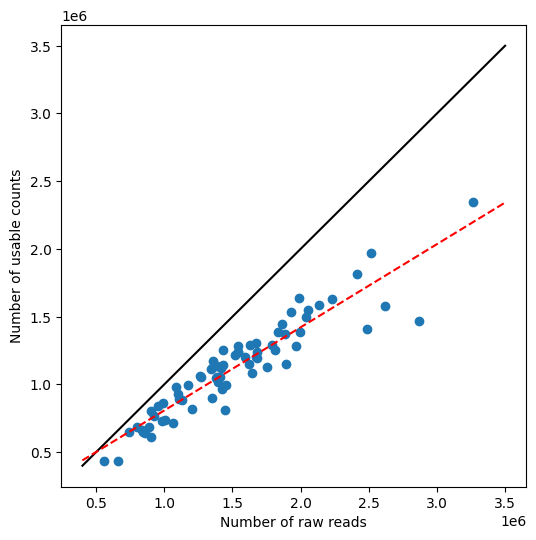

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(sample_datasheet.raw_reads, sample_datasheet.usable_reads)

plt.plot([400000, 3500000], [400000, 3500000], '-k')

plt.xlabel('Number of raw reads')
plt.ylabel('Number of usable counts')

plt.plot([x for x in range(400000, 3500000, 5000)], [(x*usable_stats[0])+usable_stats[1] for x in range(400000, 3500000, 5000)], 'r--')

Text(0, 0.5, 'Number of usable reads')

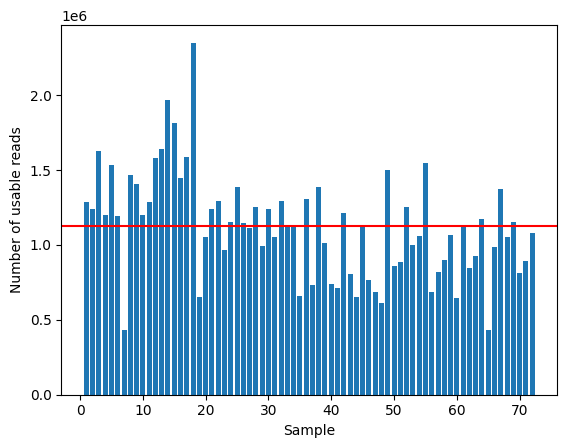

In [23]:
plt.bar([x for x in sample_datasheet.index], [sample_datasheet.at[x, 'usable_reads'] for x in sample_datasheet.index])
plt.axhline(sample_datasheet['usable_reads'].median(), color='red')
plt.xlabel('Sample')
plt.ylabel('Number of usable reads')

In [24]:
sgRNA_df.to_csv('./sgRNAs_annot_wcounts.csv', sep=',')

In [75]:
for condition in condition_list:
    for induction in ['ATC', 'NoATC']:
        std_col_name = 'std_log2fc_'+induction+'_'+condition
        col_start='log2fc_'+induction+'_'+condition
        
        
        sgRNA_df[std_col_name] = sgRNA_df[[(col_start+'_T3_1'),(col_start+'_T3_2'),(col_start+'_T3_3')]].std(axis=1)

In [76]:
[x for x in sgRNA_df.columns if 'YPD' in x]

['ATC_YPD_T3_1',
 'ATC_YPD_T3_2',
 'ATC_YPD_T3_3',
 'NoATC_YPD_T3_1',
 'NoATC_YPD_T3_2',
 'NoATC_YPD_T3_3',
 'freq_ATC_YPD_T3_1',
 'freq_ATC_YPD_T3_2',
 'freq_ATC_YPD_T3_3',
 'freq_NoATC_YPD_T3_1',
 'freq_NoATC_YPD_T3_2',
 'freq_NoATC_YPD_T3_3',
 'log2fc_NoATC_YPD_T3_1',
 'log2fc_ATC_YPD_T3_1',
 'log2fc_NoATC_YPD_T3_2',
 'log2fc_ATC_YPD_T3_2',
 'log2fc_NoATC_YPD_T3_3',
 'log2fc_ATC_YPD_T3_3',
 'median_log2fc_ATC_YPD',
 'median_log2fc_NoATC_YPD',
 'delta_ATC_YPD',
 'std_log2fc_ATC_YPD',
 'std_log2fc_NoATC_YPD']

In [77]:
sgRNA_df[sgRNA_df['alias']=='MMM1']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
262,C4_00560C,MMM1,265,TAGTGCCAGAGATTTCACAG,0,+,89.0,no,-54.0,54.0,...,0.069987,0.131607,0.171005,0.226472,0.306328,0.078961,0.169519,0.179530,0.103622,0.122539
263,C4_00560C,MMM1,266,AGTGCCAGAGATTTCACAGT,0,+,88.0,no,-53.0,53.0,...,0.028390,0.079991,0.029184,0.090321,0.168893,0.100023,0.061118,0.070289,0.091406,0.100557
264,C4_00560C,MMM1,267,TGCCAGAGATTTCACAGTGG,0,+,86.0,no,-51.0,51.0,...,0.077646,0.068000,0.321028,0.114415,0.228249,0.441822,0.225228,0.099919,0.275234,0.224378
265,C4_00560C,MMM1,268,CCAGAGATTTCACAGTGGGG,0,+,84.0,no,-49.0,49.0,...,0.092305,0.570479,0.091167,2.206484,0.588294,0.532134,0.056178,0.544231,0.326870,0.322377


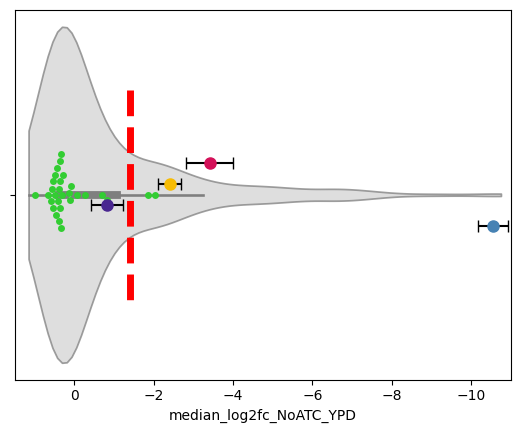

In [78]:
sns.swarmplot(sgRNA_df[is_control]['median_log2fc_NoATC_YPD'], zorder=8, color='limegreen', orient='h')
sns.violinplot(sgRNA_df[is_test]['median_log2fc_NoATC_YPD'], orient='h', color='lightgrey', cut=0, alpha=0.75)

plt.errorbar(sgRNA_df.at[262,'median_log2fc_NoATC_YPD'], -0.075, 
             xerr=sgRNA_df.at[262,'std_log2fc_NoATC_YPD']*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
plt.errorbar(sgRNA_df.at[263,'median_log2fc_NoATC_YPD'], -0.025, 
             xerr=sgRNA_df.at[263,'std_log2fc_NoATC_YPD']*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
plt.errorbar(sgRNA_df.at[264,'median_log2fc_NoATC_YPD'], 0.025, 
             xerr=sgRNA_df.at[264,'std_log2fc_NoATC_YPD']*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
plt.errorbar(sgRNA_df.at[265,'median_log2fc_NoATC_YPD'], 0.075, 
             xerr=sgRNA_df.at[265,'std_log2fc_NoATC_YPD']*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)



plt.plot([noATC_stats_df.at['median_log2fc_NoATC_YPD', 'threshold'],noATC_stats_df.at['median_log2fc_NoATC_YPD', 'threshold'] ], [-0.25, 0.25], 'r--', lw=5)

plt.xlim(1.5,-11)

plt.savefig('./figures/MMM1_violin_plot.svg',format='svg',dpi=300)

In [79]:
noATC_FC_col_list

['median_log2fc_NoATC_YPD',
 'median_log2fc_NoATC_LAC',
 'median_log2fc_NoATC_GLY',
 'median_log2fc_NoATC_ACE',
 'median_log2fc_NoATC_NACL',
 'median_log2fc_NoATC_SORB',
 'median_log2fc_NoATC_LOPH',
 'median_log2fc_NoATC_SDS',
 'median_log2fc_NoATC_5FC',
 'median_log2fc_NoATC_TUN',
 'median_log2fc_NoATC_MMS']

0
0
1
1
2
2
3
3
4
4
5
5
6


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

6
7
7
8
8
9
9
10
10


(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

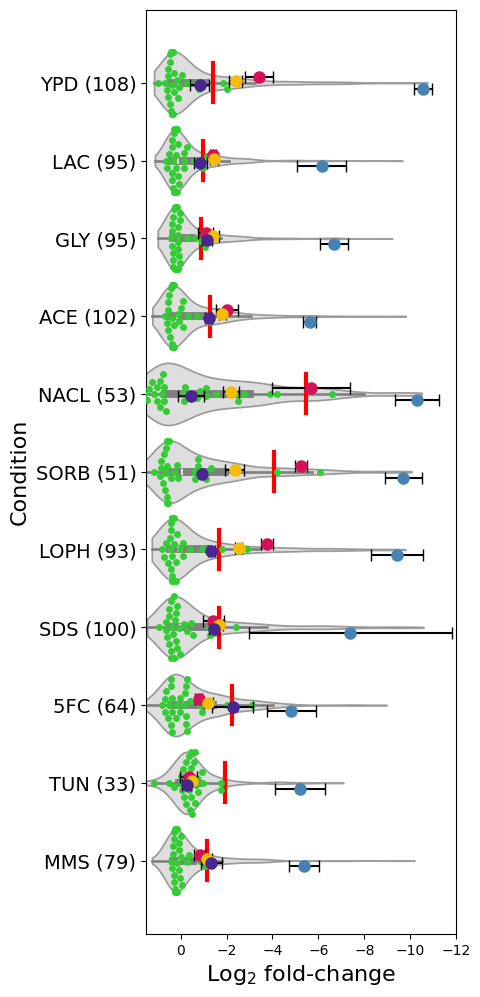

In [80]:
plt.figure(figsize=(4,12))

test_guide_list = [262,263,264,265]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

C2_07680W

In [81]:
sgRNA_df[sgRNA_df['alias']=='C2_07680W']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
198,C2_07680W,C2_07680W,201,GTTAACGTCGGTCTTTCTTC,0,-,156.0,no,-135.0,135.0,...,0.058750,0.060448,0.047270,0.152531,0.030926,0.049993,0.137574,0.074914,0.336213,0.073242
199,C2_07680W,C2_07680W,202,TTCTCCCTCTCCATTCTGTT,0,+,84.0,no,-63.0,63.0,...,0.212615,1.108940,0.310883,1.844686,0.287991,1.057555,0.144987,0.198195,0.262326,0.559346
200,C2_07680W,C2_07680W,203,CTAACCAAACAGAATGGAGA,0,-,77.0,no,-56.0,56.0,...,0.812950,0.277720,0.668813,0.297218,2.144560,1.576186,0.020191,0.859542,1.076933,1.596962
201,C2_07680W,C2_07680W,204,TCTAACCAAACAGAATGGAG,0,-,76.0,no,-55.0,55.0,...,0.227094,0.414760,0.136186,0.213838,0.402723,1.561131,0.068463,0.570796,0.476432,2.882976


0
0
1
1
2
2
3
3
4
4
5


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

5
6
6
7
7
8


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

8
9
9
10
10


(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

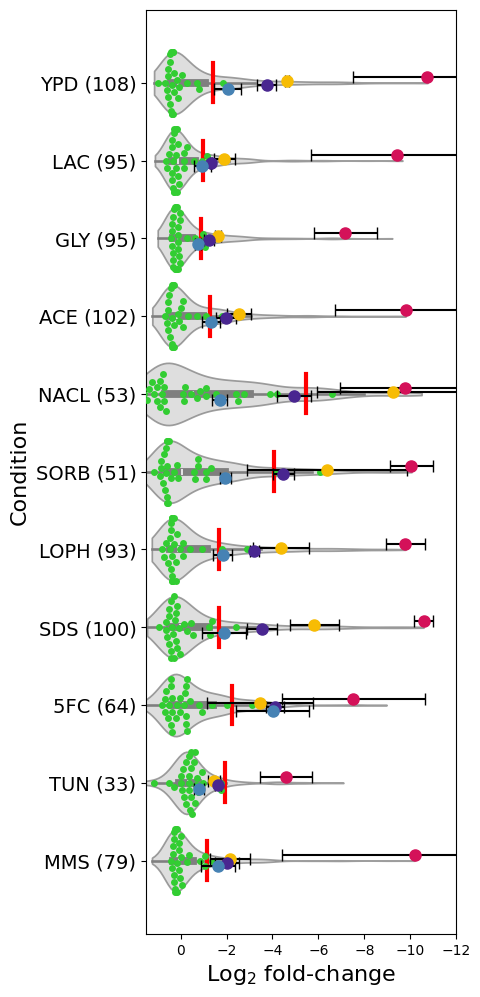

In [82]:
plt.figure(figsize=(4,12))

test_guide_list = [201,202,203,204]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

HSP90

In [83]:
sgRNA_df[sgRNA_df['alias']=='HSP90']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
518,C7_02030W,HSP90,521,ATTTTTCCAGTGGTCTCCGT,0,+,131.0,no,-99.0,99.0,...,0.422566,1.407254,0.516130,1.591218,0.115964,1.556599,0.460864,2.157690,0.132030,0.331006
519,C7_02030W,HSP90,522,TGGCAACCAACGGAGACCAC,0,-,122.0,no,-90.0,90.0,...,0.670819,0.486655,0.255528,1.384844,0.774426,0.435891,0.698539,1.072863,0.851997,1.154808
520,C7_02030W,HSP90,523,AGGTAGTAATATGGTGCTGC,0,-,267.0,no,-235.0,235.0,...,0.202195,0.445726,0.375771,0.380262,0.730419,0.141972,0.223951,0.586636,0.583509,0.121969
521,C7_02030W,HSP90,524,AACGGGAGGAGTTGATAAAC,0,-,70.0,no,-38.0,38.0,...,0.030287,0.111776,0.068952,0.143666,0.053815,0.077651,0.028223,0.020848,0.060695,0.112114


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

7
8
8
9
9
10
10


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

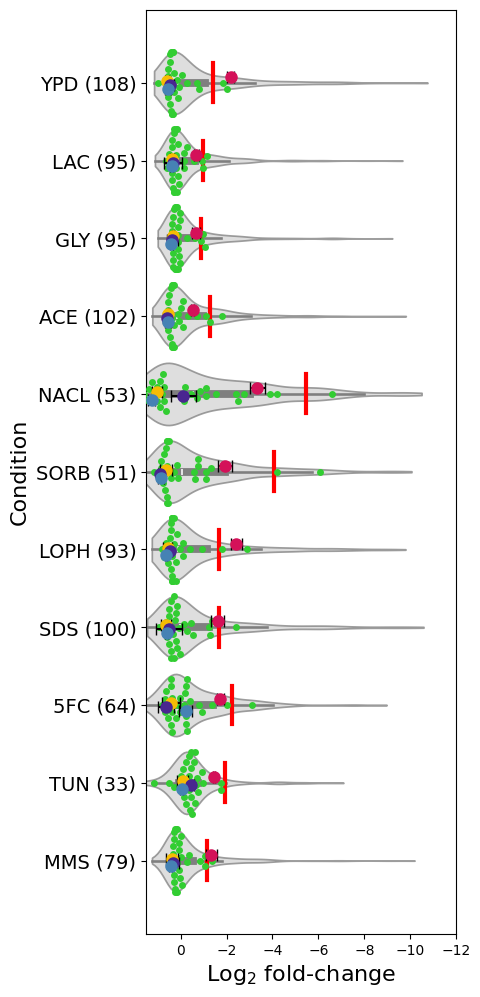

In [84]:
plt.figure(figsize=(4,12))

test_guide_list = [521,522,523,524]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

Ask1 

In [85]:
sgRNA_df[sgRNA_df['alias']=='ASK1']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
270,C4_01150W,ASK1,273,GTGTGTTTAAGGGATGCTGG,0,+,280.0,no,-252.0,252.0,...,0.061505,0.065178,0.347991,0.129559,0.047924,0.310079,0.046318,0.161973,0.320701,0.043198
271,C4_01150W,ASK1,274,TGGTGGTAAATGGTTAGTGG,0,+,205.0,no,-177.0,177.0,...,0.247876,1.224340,0.184919,0.382578,0.221278,0.465438,0.210413,0.207058,0.225422,0.784952
272,C4_01150W,ASK1,275,AAATGGTTAGTGGTGGTAAG,0,+,198.0,no,-170.0,170.0,...,0.134901,1.030111,0.406006,2.277300,0.501181,1.501432,0.391280,1.731201,0.494793,2.594755
273,C4_01150W,ASK1,276,TTAGTGGTGGTAAGTGGAGG,0,+,192.0,no,-164.0,164.0,...,0.192815,0.987399,1.974508,0.553387,0.512540,2.304264,1.142379,0.676845,0.370420,2.461937


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7
7
8
8
9
9
10
10


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

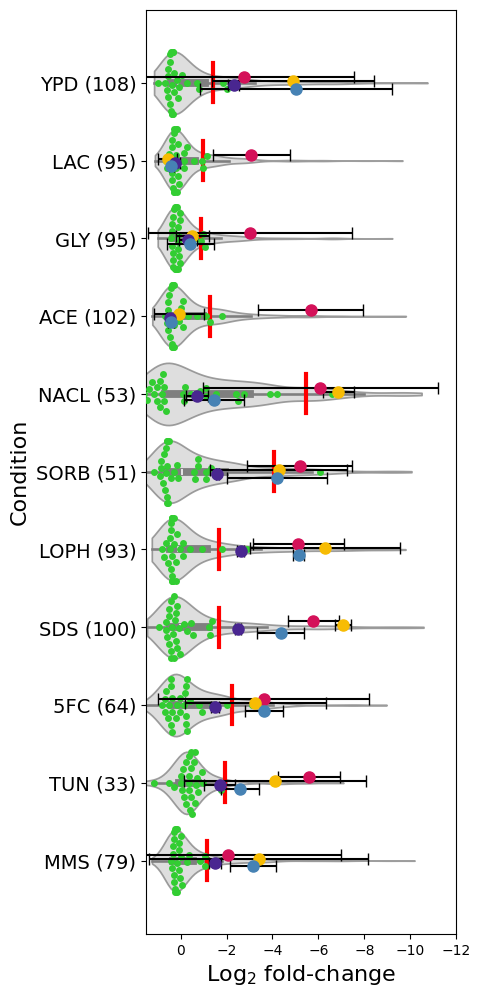

In [86]:
plt.figure(figsize=(4,12))

test_guide_list = [273,274,275,276]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

MRLP33 

In [87]:
sgRNA_df[sgRNA_df['alias']=='MRPL33']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
218,C3_01080W,MRPL33,221,CGAAAGCTCAACGTTAAGGA,0,+,103.0,no,-27.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,C3_01080W,MRPL33,222,CAACGTTAAGGAAGGAAGGA,0,+,95.0,no,-19.0,19.0,...,0.268343,1.498577,0.245555,0.589124,0.210314,0.943925,0.243413,0.108310,0.046550,0.843885
220,C3_01080W,MRPL33,223,TCCCGGACAACACCCAAAAC,0,+,247.0,no,-171.0,171.0,...,0.144901,0.409953,0.147158,0.230636,0.093858,0.398980,0.110285,0.316097,0.075402,0.242125
221,C3_01080W,MRPL33,224,GGTTTGCAAAAACACATTTA,0,+,226.0,no,-150.0,150.0,...,0.149450,0.318784,0.314556,2.822533,0.296662,0.369082,0.072722,0.165055,0.169231,0.297107


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7
7
8
8
9


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

9
10
10


(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

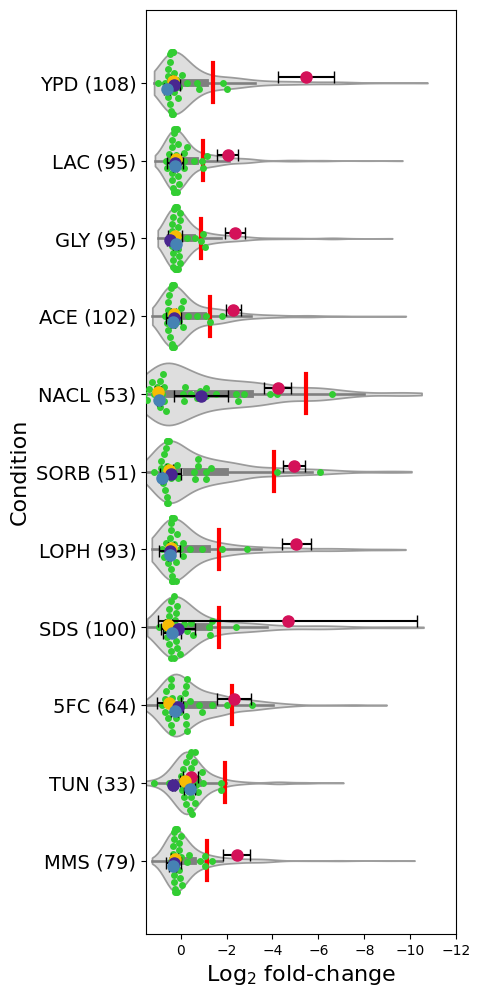

In [88]:
plt.figure(figsize=(4,12))

test_guide_list = [221,222,223,224]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

FBA1 

In [89]:
sgRNA_df[sgRNA_df['alias']=='FBA1']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
274,C4_01750C,FBA1,277,GTAGGCAAGCAGGCAGAAAG,0,+,210.0,no,-153.0,153.0,...,0.232082,1.639267,0.436249,0.167054,2.732549,1.542034,0.815438,1.986633,0.537973,2.380662
275,C4_01750C,FBA1,278,TAGGCAAGCAGGCAGAAAGT,0,+,209.0,no,-152.0,152.0,...,0.089680,0.084382,0.165995,0.064275,0.204021,0.087167,0.114241,0.336839,0.044222,0.130063
276,C4_01750C,FBA1,279,TTCTGCCTGCTTGCCTACGT,0,-,212.0,no,-155.0,155.0,...,0.237361,0.117091,0.312754,0.510471,0.337678,0.411846,0.076844,0.410838,0.091895,0.508040
277,C4_01750C,FBA1,280,TTTCTGCCTGCTTGCCTACG,0,-,211.0,no,-154.0,154.0,...,0.308509,0.546085,0.368110,0.970820,1.348737,1.008296,0.305210,0.311368,1.227357,1.084716


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

7
8
8
9
9
10
10


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 37.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

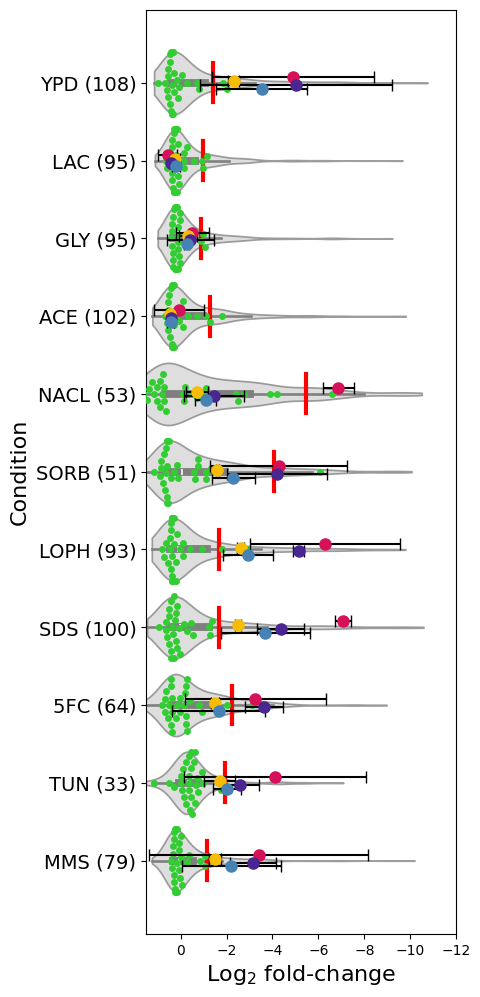

In [90]:
plt.figure(figsize=(4,12))

test_guide_list = [274,275,276,277]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

In [125]:
sgRNA_df[sgRNA_df['alias']=='C2_03560C']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
164,C2_03560C,C2_03560C,165,TGGCGCAAAGGACAAAAAAA,0,+,125.0,no,-99.0,99.0,...,0.026336,0.076645,0.060155,0.047959,0.049883,0.053173,0.052914,0.018745,0.042379,0.025620
165,C2_03560C,C2_03560C,166,AGGAAATTCGCCAGAACTCT,0,+,105.0,no,-79.0,79.0,...,0.027579,0.275140,0.078723,0.433751,0.066602,0.618880,0.263836,0.211492,0.242381,0.151927
166,C2_03560C,C2_03560C,167,GGCACTATCACCAAGAGTTC,0,-,92.0,no,-66.0,66.0,...,0.122614,0.802362,0.166023,0.618364,0.207768,0.925236,0.088407,0.119066,0.249642,0.335772
167,C2_03560C,C2_03560C,168,CAAGAATAATGCTTGATTTC,0,-,37.0,no,-11.0,11.0,...,0.082725,0.538994,0.223195,0.698613,0.832843,1.107567,0.357399,0.067043,0.569884,0.501606


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7
7
8
8
9
9
10
10


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.4138192

(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

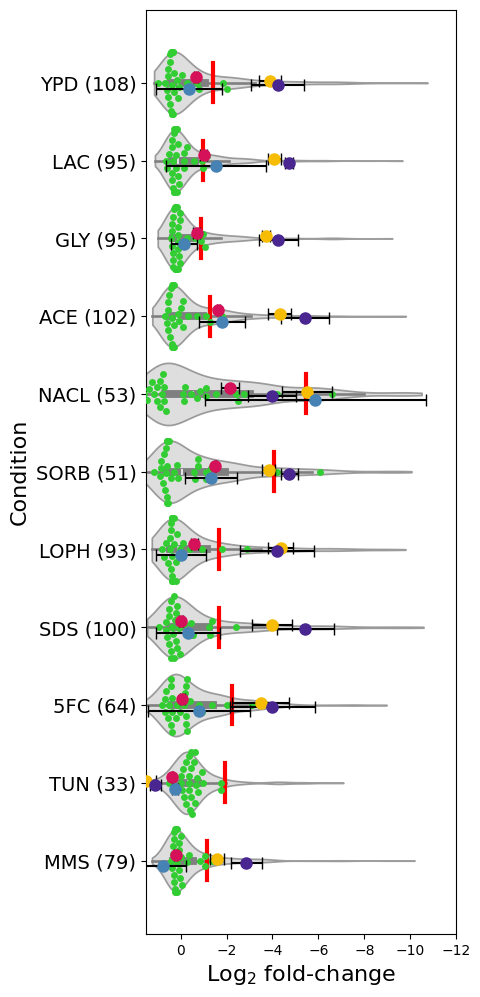

In [126]:
plt.figure(figsize=(4,12))

test_guide_list = [164,165,166,167]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

In [138]:
sgRNA_df[sgRNA_df['alias']=='SPT23']

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS
214,C2_10280C,SPT23,217,AAAGTGGAAAGTGGTGGAGG,0,-,150.0,no,11.0,11.0,...,0.150483,0.275666,0.436661,0.188420,0.446132,1.253914,0.245854,0.411004,0.275734,0.403203
215,C2_10280C,SPT23,218,TGTGTGTAATAAGTGTGTGT,0,-,281.0,no,-120.0,120.0,...,0.198960,0.286800,0.198017,0.215803,0.164009,0.341628,0.109475,0.134554,0.146570,0.133433
216,C2_10280C,SPT23,219,TTGAGTAGGCGGGTGGTAGT,0,-,246.0,no,-85.0,85.0,...,0.227201,1.538753,0.045849,1.998675,0.310471,2.552566,0.166668,1.694936,0.785917,1.408205
217,C2_10280C,SPT23,220,TTTGAGTAGGCGGGTGGTAG,0,-,245.0,no,-84.0,84.0,...,0.095363,0.254846,0.166744,0.159352,0.289745,0.373517,0.291111,0.229924,0.391497,0.111237


0
0
1
1
2
2
3
3
4
4
5
5
6
6
7
7
8


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926

8
9
9
10
10


/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 37.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 48.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

(1.5, -12.0)

/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 24.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.41381926.0/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 17.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/localscratch/phidesp.413819

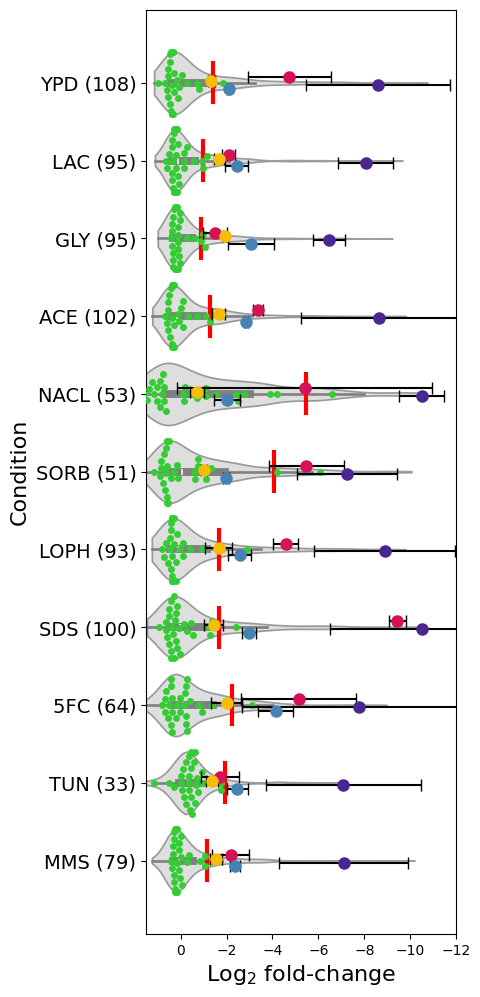

In [139]:
plt.figure(figsize=(4,12))

test_guide_list = [214,215,216,217]

y_loc = 0

for condition in noATC_FC_col_list:
    
    std_col = condition.replace('median', 'std')
    
    print(y_loc)
    sns.swarmplot(x=sgRNA_df[is_control][condition], y = y_loc, zorder=8, color='limegreen', orient='h')
    sns.violinplot(x=sgRNA_df[is_test][condition], y = y_loc, orient='h', color='lightgrey', cut=0, alpha=0.75)
    print(y_loc)
    plt.plot([noATC_stats_df.at[condition, 'threshold'],noATC_stats_df.at[condition, 'threshold'] ], [(y_loc-0.25), (y_loc+0.25)], 'r-', lw=3)
    
    plt.errorbar(sgRNA_df.at[test_guide_list[0], condition], y_loc-0.075, 
             xerr=sgRNA_df.at[test_guide_list[0], std_col]*2, 
             color='#d41159', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[1],condition], y_loc-0.025, 
             xerr=sgRNA_df.at[test_guide_list[1],std_col]*2, 
             color='#f7bc04', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[2],condition], y_loc+0.025, 
             xerr=sgRNA_df.at[test_guide_list[2],std_col]*2, 
             color='#492690', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)
    plt.errorbar(sgRNA_df.at[test_guide_list[3],condition], y_loc+0.075, 
             xerr=sgRNA_df.at[test_guide_list[3],std_col]*2, 
             color='steelblue', marker='o', zorder=9, ms=8,elinewidth=1.5,ecolor='k',capsize=4)

    
    y_loc+=1

    
plt.yticks(range(0,11), ['YPD (108)', 'LAC (95)', 'GLY (95)', 'ACE (102)', 'NACL (53)', 'SORB (51)', 'LOPH (93)', 
                         'SDS (100)', '5FC (64)', 'TUN (33)', 'MMS (79)'], fontsize=14)
plt.ylabel('Condition', fontsize=16)

plt.xlabel('Log$_{2}$ fold-change', fontsize=16)

#plt.legend([str(x) for x in test_guide_list], loc='upper right', bbox_to_anchor=(1.25, 0.5))

plt.xlim(1.5,-12)

In [108]:
noATC_FC_col_list_no_TUN = ['median_log2fc_NoATC_YPD',
                             'median_log2fc_NoATC_LAC',
                             'median_log2fc_NoATC_GLY',
                             'median_log2fc_NoATC_ACE',
                             'median_log2fc_NoATC_NACL',
                             'median_log2fc_NoATC_SORB',
                             'median_log2fc_NoATC_LOPH',
                             'median_log2fc_NoATC_SDS',
                             'median_log2fc_NoATC_5FC',
                            'median_log2fc_NoATC_MMS']

In [111]:
hit_df_no_TUN = pd.DataFrame(gene_hit_counts_dict).fillna(0)[noATC_FC_col_list_no_TUN]
hit_df_no_TUN

,median_log2fc_NoATC_YPD,median_log2fc_NoATC_LAC,median_log2fc_NoATC_GLY,median_log2fc_NoATC_ACE,median_log2fc_NoATC_NACL,median_log2fc_NoATC_SORB,median_log2fc_NoATC_LOPH,median_log2fc_NoATC_SDS,median_log2fc_NoATC_5FC,median_log2fc_NoATC_MMS
CR_01370C,0.037037,0.042105,0.042105,0.039216,0.000000,0.019608,0.021505,0.03,0.031250,0.012658
CR_04140W,0.037037,0.042105,0.042105,0.039216,0.000000,0.019608,0.032258,0.03,0.015625,0.025316
FBA1,0.037037,0.000000,0.000000,0.000000,0.018868,0.039216,0.043011,0.04,0.031250,0.050633
MRP20,0.027778,0.021053,0.021053,0.029412,0.000000,0.000000,0.021505,0.03,0.000000,0.025316
C2_07680W,0.027778,0.031579,0.031579,0.029412,0.056604,0.058824,0.032258,0.03,0.046875,0.037975
...,...,...,...,...,...,...,...,...,...,...
UFE1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,0.000000,0.000000
CHS1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,0.000000,0.000000
SVF1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.015625,0.000000
HOM6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.012658


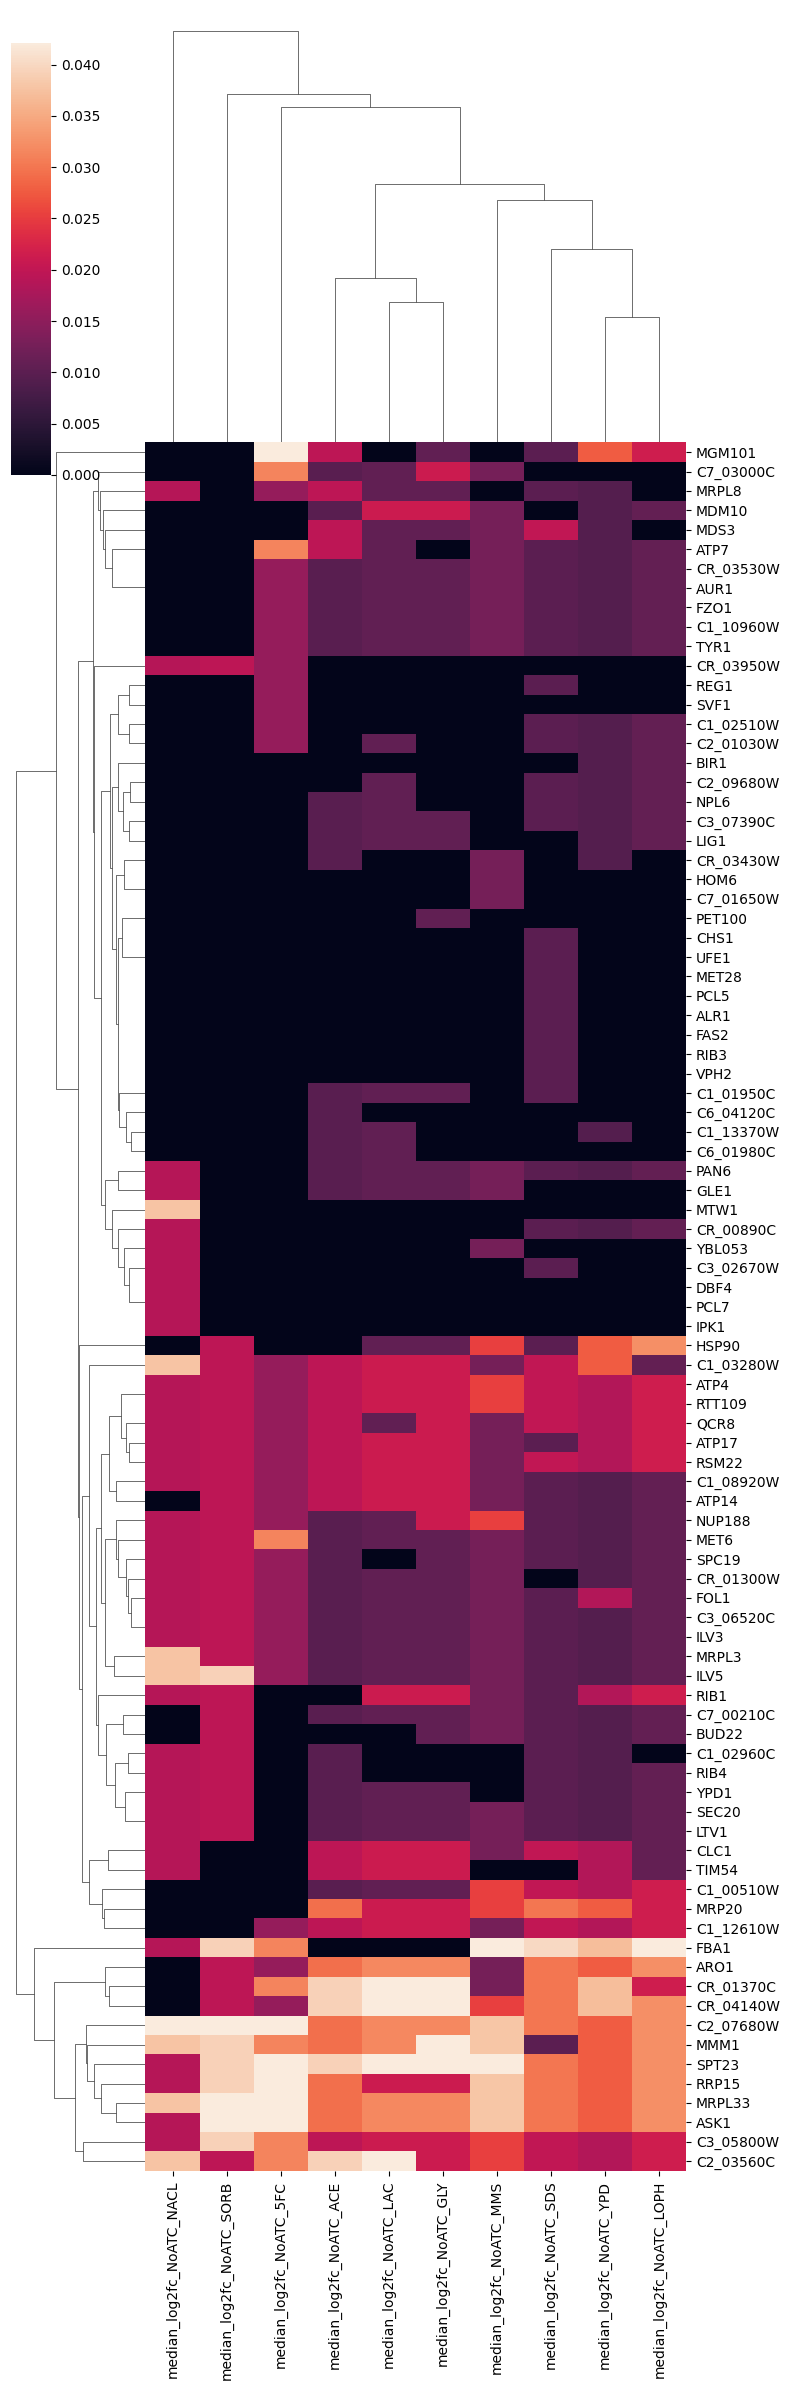

In [112]:
sns.clustermap(hit_df_no_TUN, yticklabels=True, robust=True,figsize=(8,24))

In [91]:
sgRNA_df[is_test&(sgRNA_df['median_log2fc_NoATC_YPD']>1.5)]

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS


In [92]:
sgRNA_df[is_test&(sgRNA_df['median_log2fc_NoATC_YPD']>1.5)]

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,std_log2fc_ATC_LOPH,std_log2fc_NoATC_LOPH,std_log2fc_ATC_SDS,std_log2fc_NoATC_SDS,std_log2fc_ATC_5FC,std_log2fc_NoATC_5FC,std_log2fc_ATC_TUN,std_log2fc_NoATC_TUN,std_log2fc_ATC_MMS,std_log2fc_NoATC_MMS


In [93]:
sgRNA_df.loc[45][['log2fc_NoATC_YPD_T3_1',
 'log2fc_ATC_YPD_T3_1',
 'log2fc_NoATC_YPD_T3_2',
 'log2fc_ATC_YPD_T3_2',
 'log2fc_NoATC_YPD_T3_3',
 'log2fc_ATC_YPD_T3_3']]

log2fc_NoATC_YPD_T3_1     1.89587
log2fc_ATC_YPD_T3_1      2.208782
log2fc_NoATC_YPD_T3_2         NaN
log2fc_ATC_YPD_T3_2           NaN
log2fc_NoATC_YPD_T3_3         NaN
log2fc_ATC_YPD_T3_3      3.702184
Name: 45, dtype: object

(array([ 2.,  0.,  0.,  0.,  2.,  0.,  2.,  6., 13.,  4.]),
 array([-2.07041416, -1.77644686, -1.48247955, -1.18851224, -0.89454494,
        -0.60057763, -0.30661032, -0.01264302,  0.28132429,  0.5752916 ,
         0.8692589 ]),
 <BarContainer object of 10 artists>)

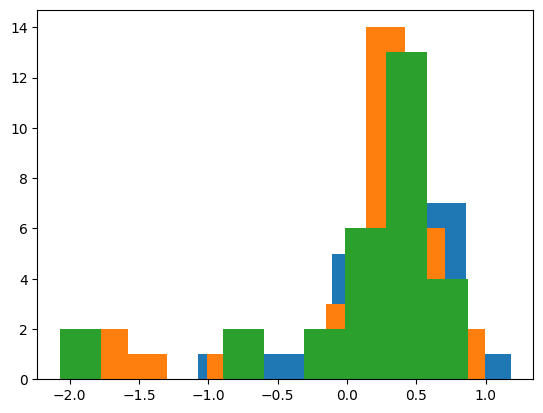

In [94]:
plt.hist(sgRNA_df[is_control]['log2fc_NoATC_YPD_T3_1'])
plt.hist(sgRNA_df[is_control]['log2fc_NoATC_YPD_T3_2'])
plt.hist(sgRNA_df[is_control]['log2fc_NoATC_YPD_T3_3'])

{'whiskers': [<matplotlib.lines.Line2D at 0x14bfd7872950>,
 'caps': [<matplotlib.lines.Line2D at 0x14bfd7873c10>,
 'boxes': [<matplotlib.lines.Line2D at 0x14bfd7872210>,
 'medians': [<matplotlib.lines.Line2D at 0x14bfd787cf10>,
 'fliers': [<matplotlib.lines.Line2D at 0x14bfd787d850>,
 'means': []}

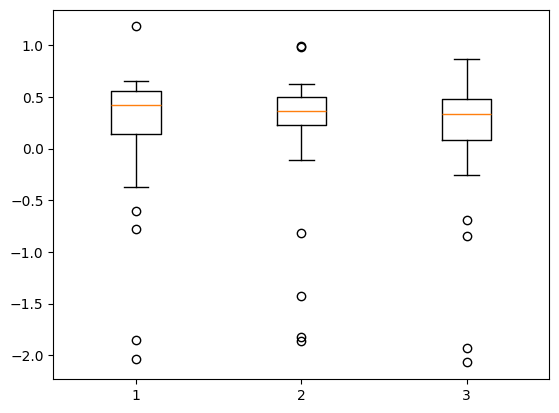

In [95]:
plt.boxplot([sgRNA_df[is_control]['log2fc_NoATC_YPD_T3_1'], sgRNA_df[is_control]['log2fc_NoATC_YPD_T3_2'], sgRNA_df[is_control]['log2fc_NoATC_YPD_T3_3']])

{'whiskers': [<matplotlib.lines.Line2D at 0x14bfd76f9490>,
 'caps': [<matplotlib.lines.Line2D at 0x14bfd76fa750>,
 'boxes': [<matplotlib.lines.Line2D at 0x14bfd76f8dd0>,
 'medians': [<matplotlib.lines.Line2D at 0x14bfd76fbad0>,
 'fliers': [<matplotlib.lines.Line2D at 0x14bfd76fc2d0>,
 'means': []}

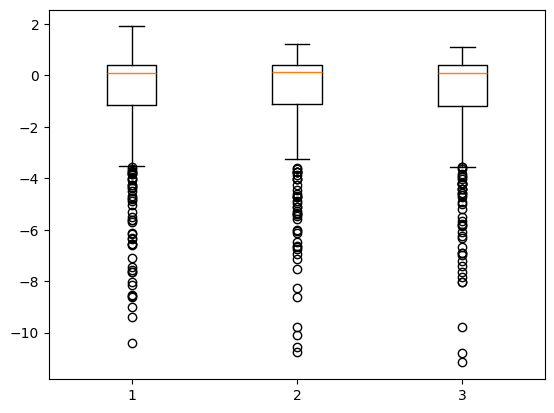

In [96]:
plt.boxplot([sgRNA_df[is_test]['log2fc_NoATC_YPD_T3_1'].dropna(),
             sgRNA_df[is_test]['log2fc_NoATC_YPD_T3_2'].dropna(), 
             sgRNA_df[is_test]['log2fc_NoATC_YPD_T3_3'].dropna()])

In [97]:
sgRNA_df[is_test][['log2fc_NoATC_YPD_T3_1','log2fc_NoATC_YPD_T3_2','log2fc_NoATC_YPD_T3_3']]

,log2fc_NoATC_YPD_T3_1,log2fc_NoATC_YPD_T3_2,log2fc_NoATC_YPD_T3_3
0,0.726151,0.682308,0.716486
1,0.525941,0.352661,0.537066
2,NaN,NaN,NaN
3,-0.125716,0.109948,0.674764
4,0.021556,-0.133389,-0.032355
...,...,...,...
517,0.452253,0.456103,0.313278
518,-2.567995,-2.673218,-2.896692
519,-4.805494,-6.128005,-4.588636
520,-0.076142,0.398238,-0.052079


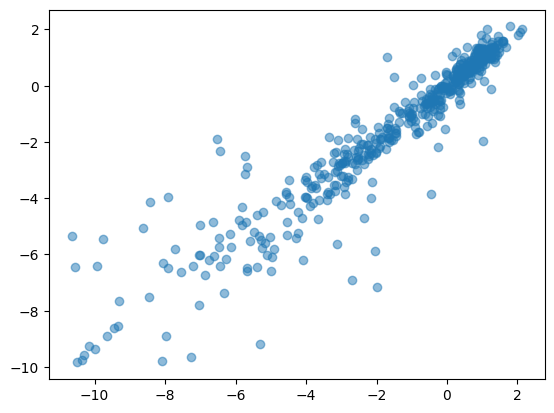

In [98]:
plt.scatter(sgRNA_df['log2fc_NoATC_NACL_T3_1'], sgRNA_df['log2fc_NoATC_NACL_T3_2'], alpha=0.5)

Text(0, 0.5, 'Fraction of sgRNAs above threshold')

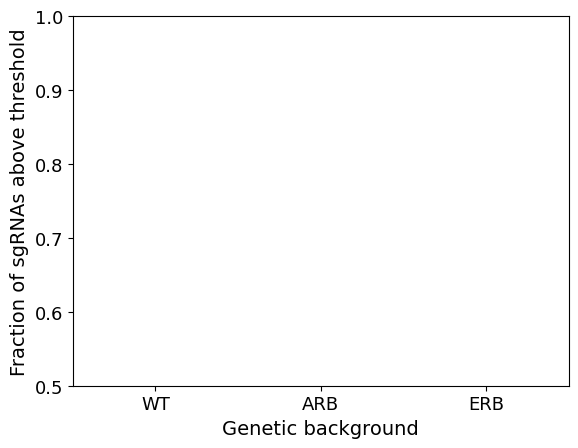

In [99]:
sgRNA_passing_filter_dists = [[len(sgRNA_df[x].dropna())/553 for x in log2_col_list if 'WT' in x],
                             [len(sgRNA_df[x].dropna())/553 for x in log2_col_list if 'ARB' in x],
                             [len(sgRNA_df[x].dropna())/553 for x in log2_col_list if 'ERB' in x]]

plt.boxplot(sgRNA_passing_filter_dists)

plt.ylim(0.5,1)

plt.xticks([1,2,3], ['WT', 'ARB', 'ERB'], fontsize=13)
plt.xlabel('Genetic background', fontsize=14)


plt.yticks(fontsize=13)
plt.ylabel('Fraction of sgRNAs above threshold', fontsize=14)

In [100]:
drug_list = ['', 'FLU_', 'CASP_']

rep_list = ['1','2','3']

inducer = ['', 'ATC_']

for drug in drug_list:
    
    for induc in inducer:
    
        col_name = 'log2fc_WT_'+induc+drug
        print(col_name)

        rep_slice = sgRNA_df[[(col_name+'1'), (col_name+'2'), (col_name+'3')]]
        print(len(rep_slice.dropna()))
    

log2fc_WT_


KeyError: "None of [Index(['log2fc_WT_1', 'log2fc_WT_2', 'log2fc_WT_3'], dtype='object')] are in the [columns]"

In [ ]:
sgRNA_df[log2_col_list].dropna()

In [ ]:
436/553

In [ ]:
wt_log2_cols = ['log2fc_WT_1',
 'log2fc_WT_ATC_1',
 'log2fc_WT_2',
 'log2fc_WT_ATC_2',
 'log2fc_WT_3',
 'log2fc_WT_ATC_3',
 'log2fc_WT_FLU_1',
 'log2fc_WT_ATC_FLU_1',
 'log2fc_WT_FLU_2',
 'log2fc_WT_ATC_FLU_2',
 'log2fc_WT_FLU_3',
 'log2fc_WT_ATC_FLU_3',
 'log2fc_WT_CASP_1',
 'log2fc_WT_ATC_CASP_1',
 'log2fc_WT_CASP_2',
 'log2fc_WT_ATC_CASP_2',
 'log2fc_WT_CASP_3',
 'log2fc_WT_ATC_CASP_3']

sns.clustermap(sgRNA_df[wt_log2_cols].corr(method='spearman'), figsize=(15,15), annot=True)

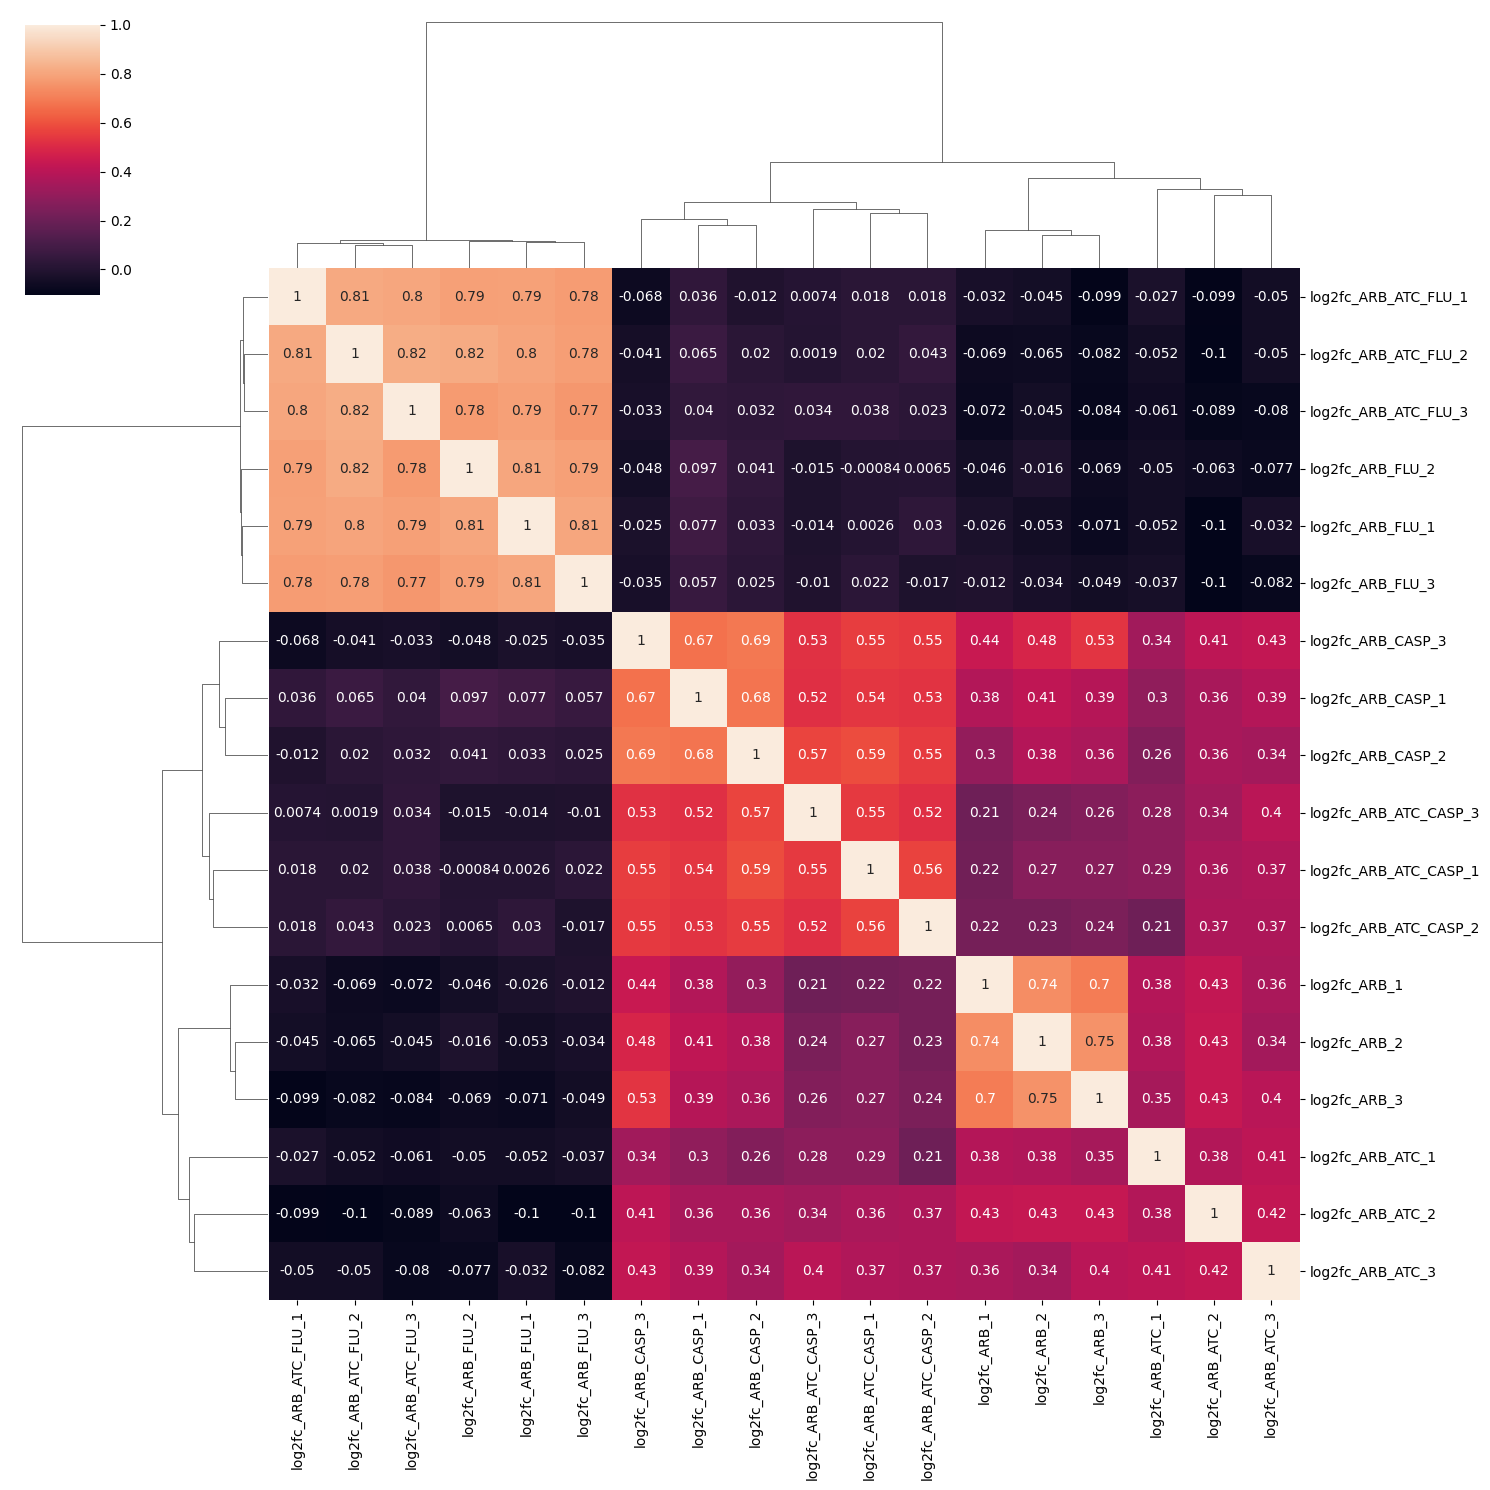

In [15]:
ARB_log2_cols =['log2fc_ARB_1',
 'log2fc_ARB_ATC_1',
 'log2fc_ARB_2',
 'log2fc_ARB_ATC_2',
 'log2fc_ARB_3',
 'log2fc_ARB_ATC_3',
 'log2fc_ARB_FLU_1',
 'log2fc_ARB_ATC_FLU_1',
 'log2fc_ARB_FLU_2',
 'log2fc_ARB_ATC_FLU_2',
 'log2fc_ARB_FLU_3',
 'log2fc_ARB_ATC_FLU_3',
 'log2fc_ARB_CASP_1',
 'log2fc_ARB_ATC_CASP_1',
 'log2fc_ARB_CASP_2',
 'log2fc_ARB_ATC_CASP_2',
 'log2fc_ARB_CASP_3',
 'log2fc_ARB_ATC_CASP_3']

sns.clustermap(sgRNA_df[ARB_log2_cols].corr(method='spearman'), figsize=(15,15), annot=True)

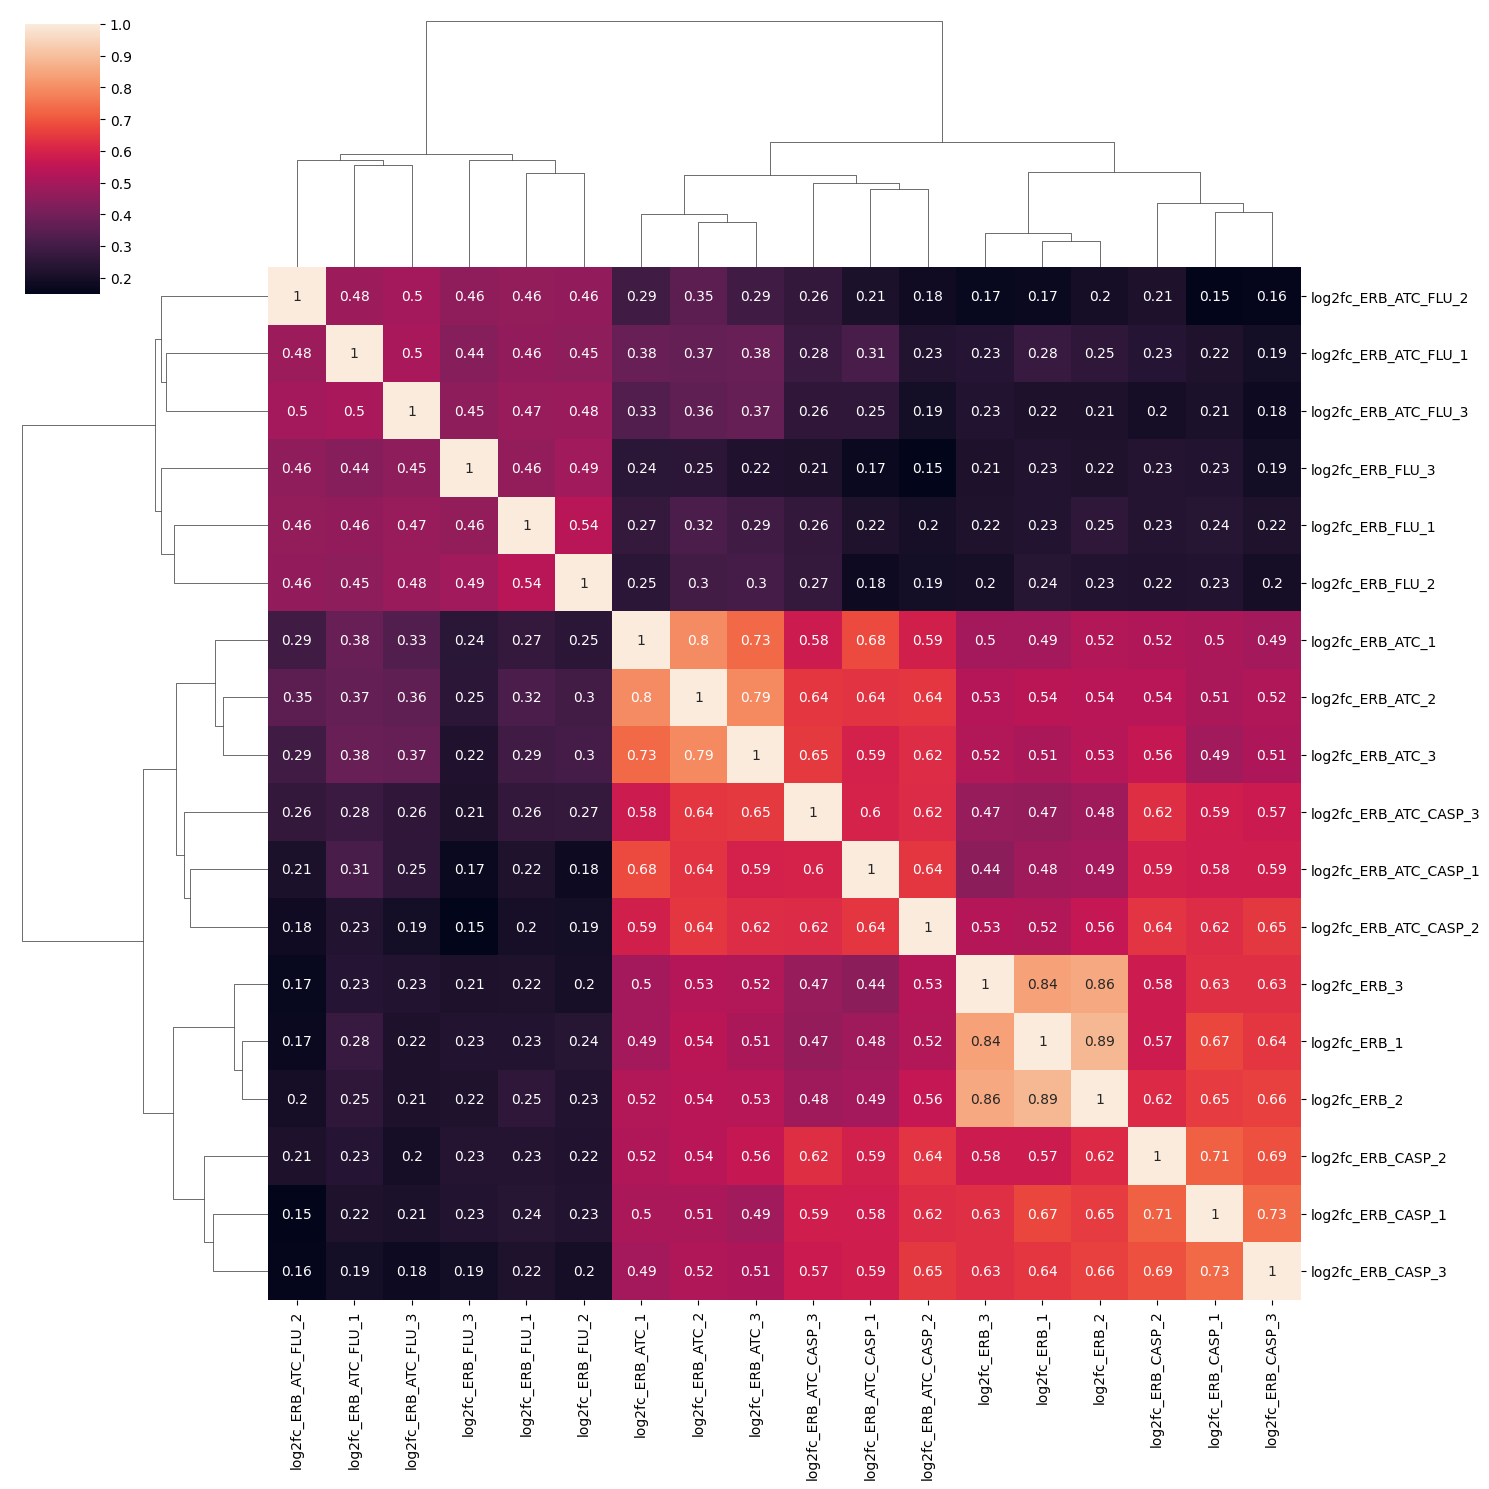

In [16]:
ERB_log2_cols = ['log2fc_ERB_1',
 'log2fc_ERB_ATC_1',
 'log2fc_ERB_2',
 'log2fc_ERB_ATC_2',
 'log2fc_ERB_3',
 'log2fc_ERB_ATC_3',
 'log2fc_ERB_FLU_1',
 'log2fc_ERB_ATC_FLU_1',
 'log2fc_ERB_FLU_2',
 'log2fc_ERB_ATC_FLU_2',
 'log2fc_ERB_FLU_3',
 'log2fc_ERB_ATC_FLU_3',
 'log2fc_ERB_CASP_1',
 'log2fc_ERB_ATC_CASP_1',
 'log2fc_ERB_CASP_2',
 'log2fc_ERB_ATC_CASP_2',
 'log2fc_ERB_CASP_3',
 'log2fc_ERB_ATC_CASP_3']

sns.clustermap(sgRNA_df[ERB_log2_cols].corr(method='spearman'), figsize=(15,15), annot=True)

In [17]:
log2_col_list

['log2fc_WT_1',
 'log2fc_WT_ATC_1',
 'log2fc_WT_2',
 'log2fc_WT_ATC_2',
 'log2fc_WT_3',
 'log2fc_WT_ATC_3',
 'log2fc_WT_FLU_1',
 'log2fc_WT_ATC_FLU_1',
 'log2fc_WT_FLU_2',
 'log2fc_WT_ATC_FLU_2',
 'log2fc_WT_FLU_3',
 'log2fc_WT_ATC_FLU_3',
 'log2fc_WT_CASP_1',
 'log2fc_WT_ATC_CASP_1',
 'log2fc_WT_CASP_2',
 'log2fc_WT_ATC_CASP_2',
 'log2fc_WT_CASP_3',
 'log2fc_WT_ATC_CASP_3',
 'log2fc_ARB_1',
 'log2fc_ARB_ATC_1',
 'log2fc_ARB_2',
 'log2fc_ARB_ATC_2',
 'log2fc_ARB_3',
 'log2fc_ARB_ATC_3',
 'log2fc_ARB_FLU_1',
 'log2fc_ARB_ATC_FLU_1',
 'log2fc_ARB_FLU_2',
 'log2fc_ARB_ATC_FLU_2',
 'log2fc_ARB_FLU_3',
 'log2fc_ARB_ATC_FLU_3',
 'log2fc_ARB_CASP_1',
 'log2fc_ARB_ATC_CASP_1',
 'log2fc_ARB_CASP_2',
 'log2fc_ARB_ATC_CASP_2',
 'log2fc_ARB_CASP_3',
 'log2fc_ARB_ATC_CASP_3',
 'log2fc_ERB_1',
 'log2fc_ERB_ATC_1',
 'log2fc_ERB_2',
 'log2fc_ERB_ATC_2',
 'log2fc_ERB_3',
 'log2fc_ERB_ATC_3',
 'log2fc_ERB_FLU_1',
 'log2fc_ERB_ATC_FLU_1',
 'log2fc_ERB_FLU_2',
 'log2fc_ERB_ATC_FLU_2',
 'log2fc_ERB_FLU_3',

In [18]:
col_set = ['log2fc_WT_1',
 'log2fc_WT_ATC_1',
 'log2fc_WT_2',
 'log2fc_WT_ATC_2',
 'log2fc_WT_3',
 'log2fc_WT_ATC_3']

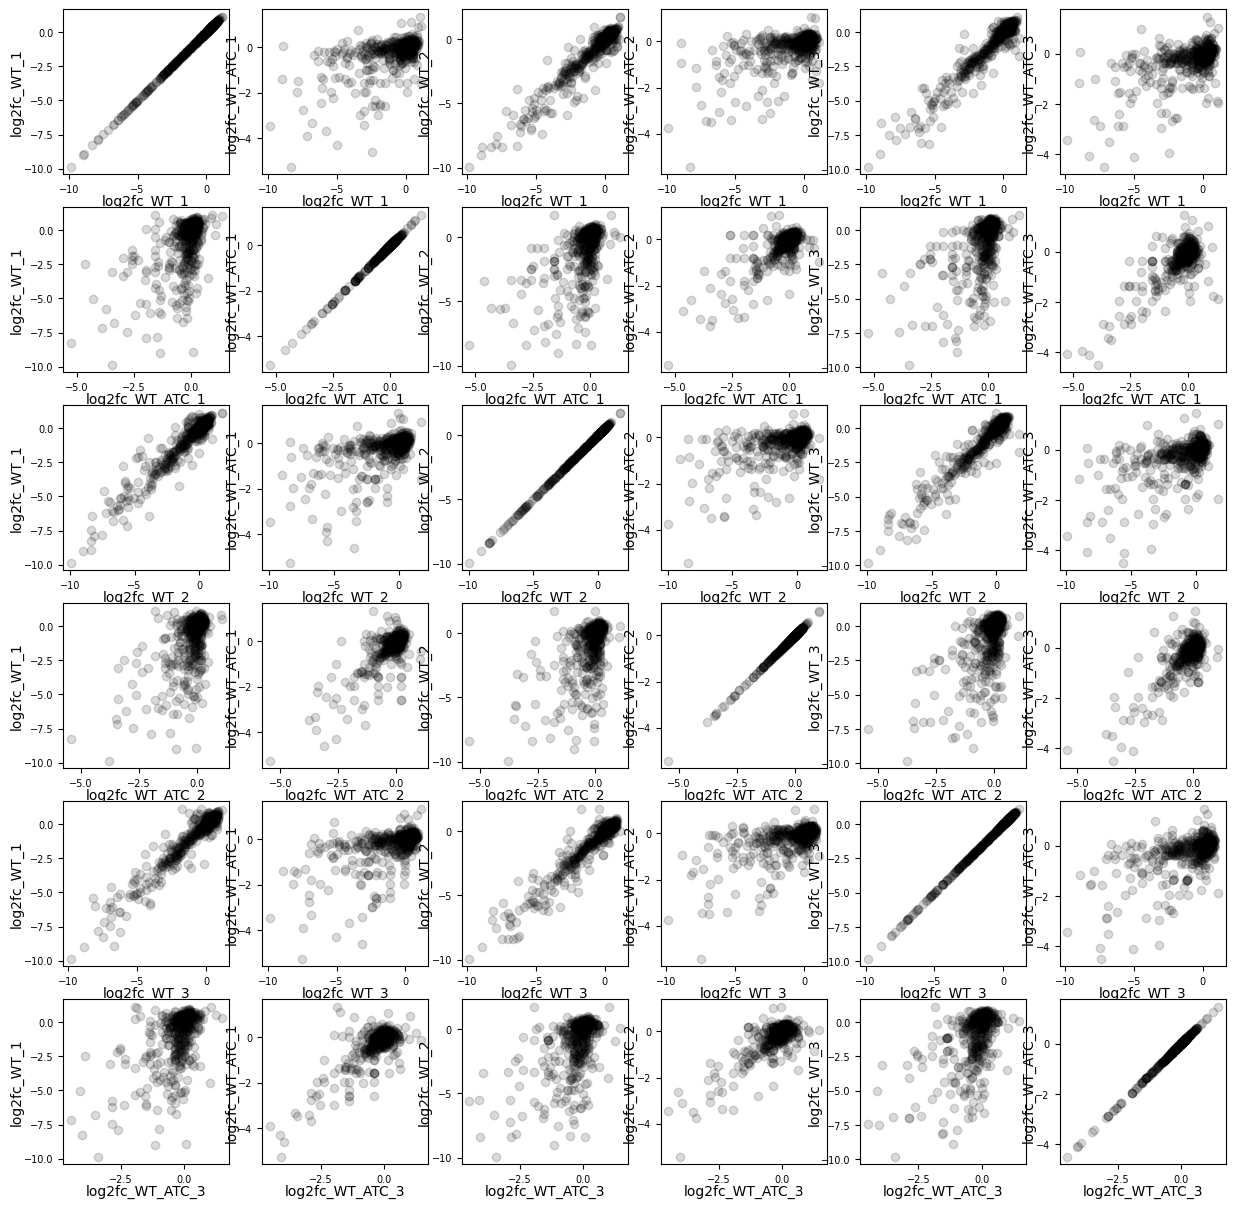

In [19]:
plt.figure(figsize=(15,15))


index = 1
for col_1 in col_set:
    for col_2 in col_set:
        plt.subplot(6,6, index)
        plt.scatter(sgRNA_df[col_1], sgRNA_df[col_2], color='k', alpha=0.15)
        # draw scatter plots in a grid
        
        rho, pval = stats.spearmanr(sgRNA_df[col_1], sgRNA_df[col_2], nan_policy='omit')
        #plt.text(-7,1, (r'$\rho$='+np.format_float_positional(rho,4)))
        #plt.text(-7,0, ('p-val='+np.format_float_scientific(pval,3)))


        
        #plt.xlim(-3.5,3)
        #plt.ylim(-3.5,3)
        # set x and y axis limits here
        
        #plt.plot([-10,-5], [-10,-5], 'r--')
        # draw a red line to show the 1:1 correlation
        
        plt.xlabel(col_1, labelpad=-0.2, fontsize=10)
        plt.ylabel(col_2, labelpad=-0.2, fontsize=10)
        
        plt.xticks(fontsize=7)
        plt.yticks(fontsize=7)
        
        index+=1

In [20]:
def set_to_nan(log2_fc, count, threshold):
    #print(log2_fc, count, threshold)
    if count <= threshold:
        return np.NaN
    else:
        return log2_fc

In [21]:
background_list = ['WT', 'ARB', 'ERB']

drug_list = ['', 'FLU_', 'CASP_']

rep_list = ['1','2','3']


log2_col_list = []

count_col=0

for background in background_list:
    for drug in drug_list:
        for rep in rep_list:
            ref_col_noATC = 'freq_'+background+'_T0_YPD_'+rep
            ref_col_ATC = 'freq_'+background+'_T0_YPD_ATC_'+rep
            count_col+=2

            strain_col_noATC = 'freq_'+background+'_T3_YPD_'+drug+rep
            log2_col_name_noATC = 'log2fc_'+background+'_'+drug+rep
            #print(ref_col_noATC,strain_col_noATC, log2_col_name_noATC)

            strain_col_ATC = 'freq_'+background+'_T3_YPD_ATC_'+drug+rep
            log2_col_name_ATC = 'log2fc_'+background+'_ATC_'+drug+rep
            #print(ref_col_ATC,strain_col_ATC, log2_col_name_ATC)

            log2_col_list.append(log2_col_name_noATC)
            log2_col_list.append(log2_col_name_ATC)
            
            sgRNA_df[log2_col_name_noATC] = np.log2(sgRNA_df[strain_col_noATC]) - np.log2(sgRNA_df[ref_col_noATC])
            sgRNA_df[log2_col_name_noATC] = sgRNA_df.apply(lambda x: set_to_nan(x[log2_col_name_noATC], x[(background+'_T0_YPD_'+rep)], 50),axis=1)
            print('dropped '+str(553-len(sgRNA_df[log2_col_name_noATC].dropna()))+' for column '+log2_col_name_noATC)
            #print((background+'_T0_YPD_'+rep))
            
            
            sgRNA_df[log2_col_name_ATC] = np.log2(sgRNA_df[strain_col_ATC]) - np.log2(sgRNA_df[ref_col_ATC])
            sgRNA_df[log2_col_name_ATC] = sgRNA_df.apply(lambda x: set_to_nan(x[log2_col_name_ATC], x[ref_col_ATC], 50),axis=1)
                
print(count_col)
sgRNA_df

dropped 50 for column log2fc_WT_1
dropped 46 for column log2fc_WT_2
dropped 58 for column log2fc_WT_3
dropped 50 for column log2fc_WT_FLU_1
dropped 46 for column log2fc_WT_FLU_2
dropped 58 for column log2fc_WT_FLU_3
dropped 50 for column log2fc_WT_CASP_1
dropped 46 for column log2fc_WT_CASP_2
dropped 58 for column log2fc_WT_CASP_3
dropped 21 for column log2fc_ARB_1
dropped 18 for column log2fc_ARB_2
dropped 23 for column log2fc_ARB_3
dropped 21 for column log2fc_ARB_FLU_1
dropped 18 for column log2fc_ARB_FLU_2
dropped 23 for column log2fc_ARB_FLU_3
dropped 21 for column log2fc_ARB_CASP_1
dropped 18 for column log2fc_ARB_CASP_2
dropped 23 for column log2fc_ARB_CASP_3
dropped 24 for column log2fc_ERB_1
dropped 19 for column log2fc_ERB_2
dropped 22 for column log2fc_ERB_3
dropped 24 for column log2fc_ERB_FLU_1
dropped 19 for column log2fc_ERB_FLU_2
dropped 22 for column log2fc_ERB_FLU_3
dropped 24 for column log2fc_ERB_CASP_1
dropped 19 for column log2fc_ERB_CASP_2
dropped 22 for column l

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,...,log2fc_ERB_FLU_2,log2fc_ERB_ATC_FLU_2,log2fc_ERB_FLU_3,log2fc_ERB_ATC_FLU_3,log2fc_ERB_CASP_1,log2fc_ERB_ATC_CASP_1,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,...,-2.596368,NaN,-2.452264,NaN,-0.396387,NaN,-0.455223,NaN,0.692648,NaN
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,...,-2.212797,NaN,-2.324902,NaN,-0.029998,NaN,-0.123005,NaN,0.381692,NaN
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,...,-2.287496,NaN,-1.846543,NaN,-0.299656,NaN,-5.956566,NaN,-1.308382,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,...,-2.149993,NaN,-3.465320,NaN,0.562905,NaN,-1.049675,NaN,0.498495,NaN
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,...,-0.891142,NaN,-0.919140,NaN,-0.391578,NaN,-0.000624,NaN,-0.029793,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,...,-1.670618,NaN,-3.063806,NaN,0.267217,NaN,0.118377,NaN,0.093505,NaN
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,...,-3.201589,NaN,-3.227557,NaN,-0.882535,NaN,-0.829913,NaN,-0.247219,NaN
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,...,-1.304833,NaN,-2.316006,NaN,0.708303,NaN,0.525149,NaN,0.594143,NaN
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,...,-0.838385,NaN,-0.384612,NaN,0.271068,NaN,0.213023,NaN,-0.074295,NaN


ValueError: The condensed distance matrix must contain only finite values.

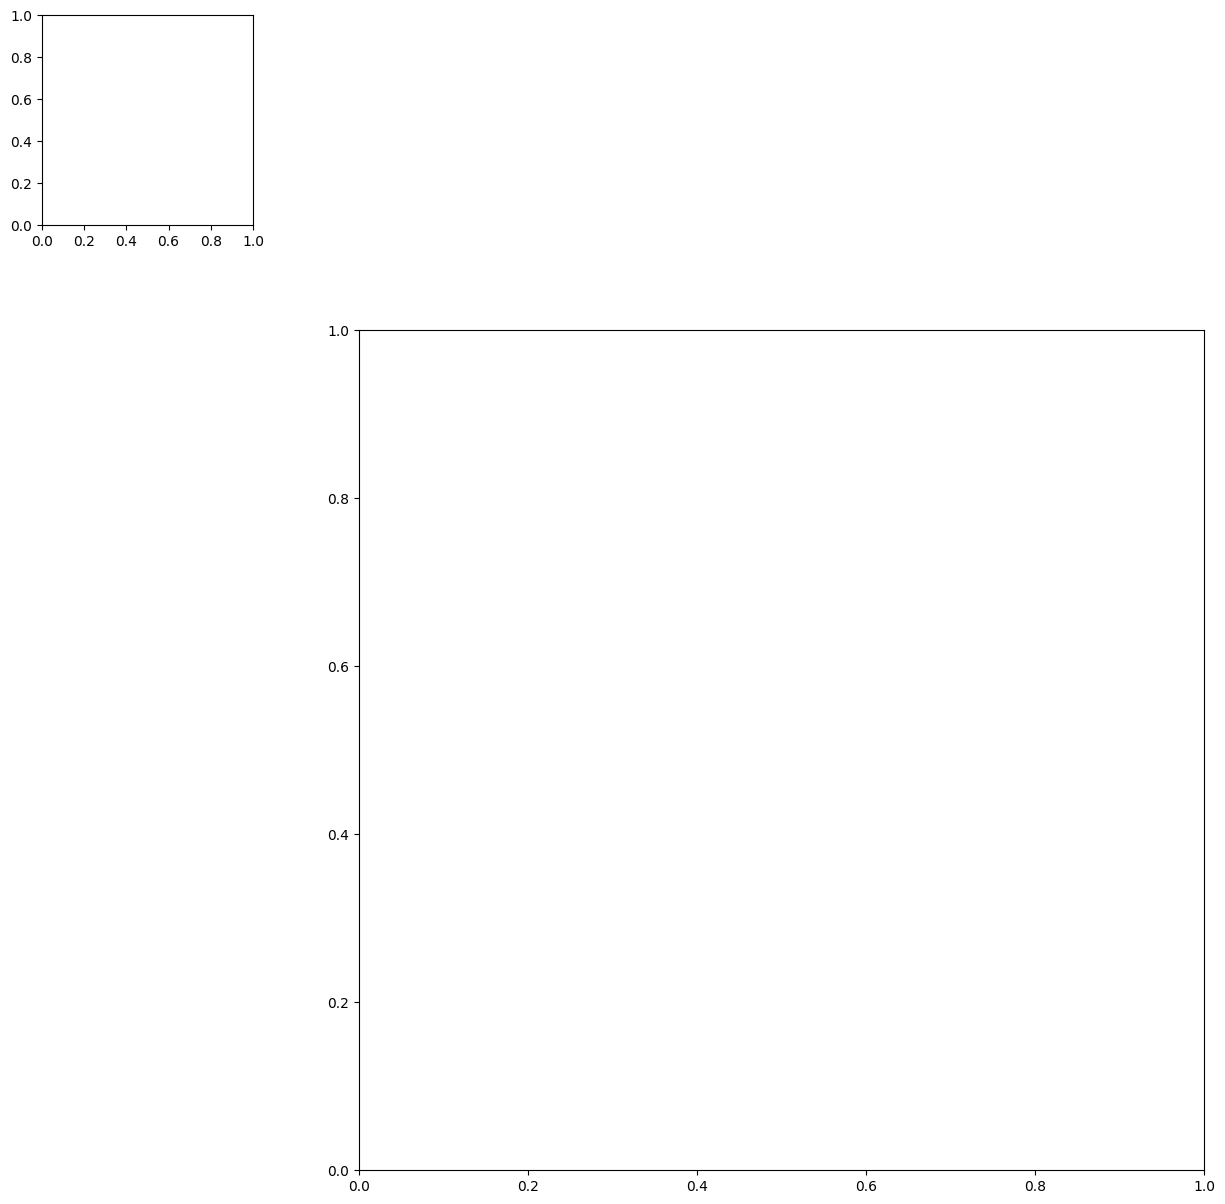

In [22]:
wt_log2_cols = ['log2fc_WT_1',
 'log2fc_WT_ATC_1',
 'log2fc_WT_2',
 'log2fc_WT_ATC_2',
 'log2fc_WT_3',
 'log2fc_WT_ATC_3',
 'log2fc_WT_FLU_1',
 'log2fc_WT_ATC_FLU_1',
 'log2fc_WT_FLU_2',
 'log2fc_WT_ATC_FLU_2',
 'log2fc_WT_FLU_3',
 'log2fc_WT_ATC_FLU_3',
 'log2fc_WT_CASP_1',
 'log2fc_WT_ATC_CASP_1',
 'log2fc_WT_CASP_2',
 'log2fc_WT_ATC_CASP_2',
 'log2fc_WT_CASP_3',
 'log2fc_WT_ATC_CASP_3']

sns.clustermap(sgRNA_df[wt_log2_cols].corr(method='spearman'), figsize=(15,15), annot=True)

In [ ]:
for col in log2_col_list:
    # print the number of reads for each library
    
    plt.boxplot(sgRNA_df[col].dropna(), positions=[x])
    x+=1

In [31]:
sgRNA_df[log2_col_list].corr(method='spearman')

,log2fc_WT_1,log2fc_WT_ATC_1,log2fc_WT_2,log2fc_WT_ATC_2,log2fc_WT_3,log2fc_WT_ATC_3,log2fc_WT_FLU_1,log2fc_WT_ATC_FLU_1,log2fc_WT_FLU_2,log2fc_WT_ATC_FLU_2,...,log2fc_ERB_FLU_2,log2fc_ERB_ATC_FLU_2,log2fc_ERB_FLU_3,log2fc_ERB_ATC_FLU_3,log2fc_ERB_CASP_1,log2fc_ERB_ATC_CASP_1,log2fc_ERB_CASP_2,log2fc_ERB_ATC_CASP_2,log2fc_ERB_CASP_3,log2fc_ERB_ATC_CASP_3
log2fc_WT_1,1.000000,0.425886,0.844395,0.428997,0.832062,0.459677,-0.156777,0.106115,-0.188492,0.010983,...,0.036712,0.023783,0.054896,0.019628,0.328543,0.140214,0.253145,0.181976,0.350921,0.081991
log2fc_WT_ATC_1,0.425886,1.000000,0.463920,0.530439,0.484692,0.462861,-0.230113,0.155890,-0.150947,-0.086068,...,0.022388,0.006743,0.110665,0.018930,0.249026,0.126314,0.257568,0.183011,0.299421,0.177982
log2fc_WT_2,0.844395,0.463920,1.000000,0.498420,0.857287,0.453927,-0.210500,0.048617,-0.209671,-0.005376,...,0.028964,0.063666,0.044845,-0.006774,0.314553,0.147696,0.262608,0.202119,0.351110,0.113422
log2fc_WT_ATC_2,0.428997,0.530439,0.498420,1.000000,0.483144,0.538180,-0.254435,-0.026967,-0.195198,-0.060922,...,0.049757,-0.003043,0.059428,0.036148,0.268805,0.149336,0.224213,0.192826,0.273512,0.083449
log2fc_WT_3,0.832062,0.484692,0.857287,0.483144,1.000000,0.431587,-0.189556,0.080285,-0.214096,-0.020759,...,0.038781,0.064628,0.039075,0.026066,0.350611,0.176472,0.269983,0.203787,0.348770,0.114879
log2fc_WT_ATC_3,0.459677,0.462861,0.453927,0.538180,0.431587,1.000000,-0.221827,0.007973,-0.207389,-0.056475,...,0.028289,0.013554,0.062851,0.069172,0.282042,0.190143,0.269092,0.165804,0.254780,0.182097
log2fc_WT_FLU_1,-0.156777,-0.230113,-0.210500,-0.254435,-0.189556,-0.221827,1.000000,0.386637,0.724635,0.507337,...,0.181937,0.091106,0.062098,0.114454,-0.085424,-0.059712,-0.099941,-0.121172,-0.064389,-0.068605
log2fc_WT_ATC_FLU_1,0.106115,0.155890,0.048617,-0.026967,0.080285,0.007973,0.386637,1.000000,0.422342,0.602962,...,0.155356,0.156512,0.120399,0.118407,-0.004751,-0.005330,0.036903,-0.008028,0.070986,-0.003682
log2fc_WT_FLU_2,-0.188492,-0.150947,-0.209671,-0.195198,-0.214096,-0.207389,0.724635,0.422342,1.000000,0.506907,...,0.173945,0.103030,0.140887,0.103118,-0.117345,-0.057814,-0.122054,-0.137005,-0.089157,-0.095464
log2fc_WT_ATC_FLU_2,0.010983,-0.086068,-0.005376,-0.060922,-0.020759,-0.056475,0.507337,0.602962,0.506907,1.000000,...,0.182692,0.175942,0.125491,0.150231,-0.030700,-0.003326,-0.037695,-0.087171,-0.016575,-0.072160


## Plot log2 fold-chance correlation, all vs all

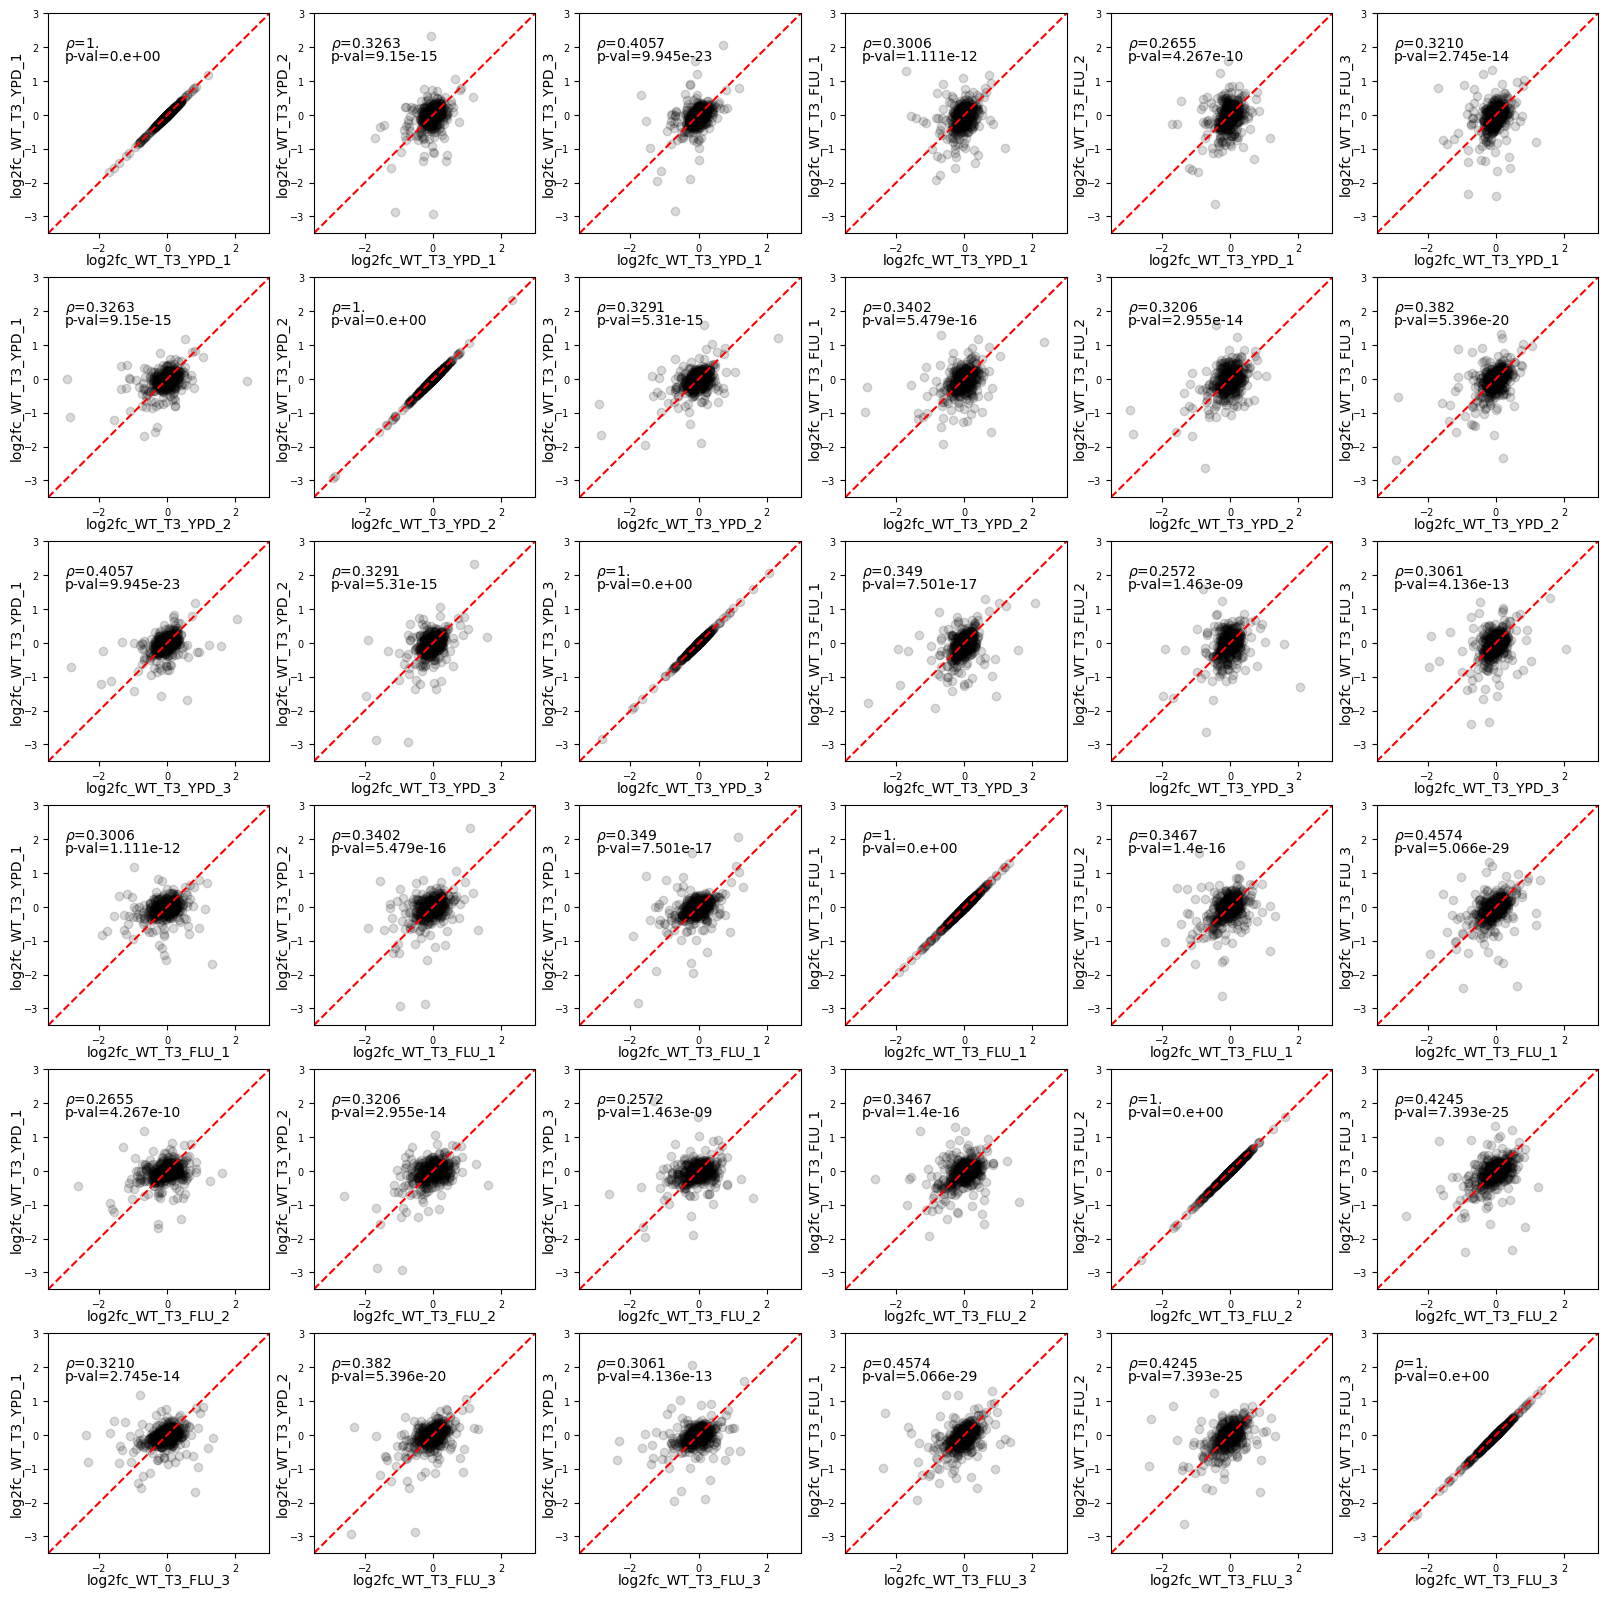

In [117]:
plt.figure(figsize=(20,20))


index = 1
for col_1 in log2_col_list:
    for col_2 in log2_col_list:
        plt.subplot(6,6, index)
        plt.scatter(sgRNA_df[col_1], sgRNA_df[col_2], color='k', alpha=0.15)
        # draw scatter plots in a grid
        
        rho, pval = stats.spearmanr(sgRNA_df[col_1], sgRNA_df[col_2], nan_policy='omit')
        plt.text(-3,2, (r'$\rho$='+np.format_float_positional(rho,4)))
        plt.text(-3,1.6, ('p-val='+np.format_float_scientific(pval,3)))


        
        plt.xlim(-3.5,3)
        plt.ylim(-3.5,3)
        # set x and y axis limits here
        
        plt.plot([-3.5,3], [-3.5,3], 'r--')
        # draw a red line to show the 1:1 correlation
        
        plt.xlabel(col_1, labelpad=-0.2, fontsize=10)
        plt.ylabel(col_2, labelpad=-0.2, fontsize=10)
        
        plt.xticks(fontsize=7)
        plt.yticks(fontsize=7)
        
        index+=1

In [ ]:
background_list = ['WT', 'ARB', 'ERB']

to_log2_col_list = ['no_ATC_1','no_ATC_2','no_ATC_3','ATC_1','ATC_2','ATC_3']

for background in background_list:
    for col in to_log2_col_list:
        strain_col = background+'_'+col
        print(strain_col)
        raw_count_df[('log2fc_'+strain_col)] = np.log2(raw_count_df[('norm_'+strain_col)]) - np.log2(raw_count_df['norm_'+background+'_T_0'])

In [31]:
sgRNA_df

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,GC_content,WT_T0_YPD_1,WT_T3_YPD_1,WT_T3_YPD_2,WT_T3_YPD_3,WT_T3_FLU_1,WT_T3_FLU_2,WT_T3_FLU_3
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,50.000000,321.0,340.0,190.0,427.0,287.0,141.0,326.0
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,35.000000,621.0,736.0,511.0,823.0,680.0,306.0,666.0
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,40.000000,137.0,136.0,100.0,200.0,127.0,50.0,170.0
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,40.000000,164.0,141.0,111.0,188.0,125.0,88.0,159.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,45.000000,5908.0,6426.0,3797.0,7567.0,5310.0,2705.0,5341.0
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,60.000000,1836.0,1959.0,1349.0,2449.0,1846.0,986.0,1720.0
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,50.000000,1420.0,1395.0,798.0,1947.0,1246.0,701.0,1338.0
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,45.000000,1070.0,1007.0,699.0,1252.0,989.0,560.0,1068.0


In [89]:
test_seq_dict = get_dict_of_seq('./vsearch_aggregate/1_aggregate.fasta')

seq_len_count = Counter()
seq_len_count_weighted = Counter()

for key, seq in test_seq_dict.items():
    seq_len_count[len(seq)]+=1
    
    seq_count = int(key.split(';size=')[1])
    seq_len_count_weighted[len(seq)]+=seq_count

set([len(x) for x in get_dict_of_seq('./vsearch_aggregate/1_aggregate.fasta').values()])

{77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95}

In [94]:
for key, seq in test_seq_dict.items():
    if 'CGCGTCCAGGTTCTTCTGGA' in seq:
        print(key, seq, len(seq))

seq76;size=1749 TTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAATA 84
seq643;size=28 TTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAAT 83
seq1087;size=9 TCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAATA 83
seq1605;size=5 TTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAATAA 85
seq2598;size=3 TTCGAGACTTGCGTAAACTATTTTTAATTTGGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAATA 84
seq3236;size=2 TTCGAGACTTGCGTAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAATA 83
seq3555;size=2 TTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAACA 84
seq4275;size=2 GTTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTTAGAGCTAGAAATAGCAAGTTAAAATA 85
seq4427;size=2 TTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTGTAGAGCTAGAAATAGCAAGTTAAAATA 84
seq4708;size=2 TTCGAGACTTGCGTAAACTATTTTTAATTTCGACGCGTCCAGGTTCTTCTGGAGTTTT

In [19]:
barcode_count_counter = Counter()

In [20]:
barcode_list = list(sgRNA_df['Barcode'])


In [22]:
for key in list(test_seq_dict.keys()):
    n_match = 0
    barcode_ids = []
    for barcode in barcode_list:
        if "AATTTCGA"+barcode+"GTTTTAGA" in test_seq_dict[key]:
            n_match+=1
            barcode_ids.append(barcode)
            if n_match > 1:
                print(key, n_match, barcode_ids)
                #print(test_seq_dict[key])
            
            
    